In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv

In [2]:
### big STA supervox
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# behaviors = ['inc', 'dec', 'flat']

n_vox=2000

event='best'
event_1='flat'

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
if event != None:
    event_times_path = os.path.join(home_path, f'{event}_event_times_split_dic.pkl')
else:
    event_times_path = os.path.join(home_path, 'event_times_split_dic.pkl')
with open(event_times_path, 'rb') as file:
    event_times_struct = pickle.load(file)
    f=list(event_times_struct.keys())[0]
    behaviors=list(event_times_struct[f].keys())
    print(f"Found behaviors: {behaviors}")

Found behaviors: ['inc', 'dec', 'flat']


## Load regressed behavior dict

In [4]:
%%time
behave_dict_path=os.path.join(later_dir,f'behave_dict_total_{event}.pkl')
behave_dict_path_1=os.path.join(later_dir,f'behave_dict_total_{event_1}.pkl')
with open(behave_dict_path, 'rb') as file:
    behave_dict_total = pickle.load(file)
    print(behave_dict_total.keys())

# with open(behave_dict_path_1, 'rb') as file:
#     behave_dict_flat = pickle.load(file)
#     print(behave_dict_flat.keys())
    

dict_keys(['inc', 'dec', 'flat'])
CPU times: user 74.8 ms, sys: 856 ms, total: 931 ms
Wall time: 5.32 s


In [5]:
# behave_dict_total['flat']=behave_dict_flat['flat']

In [6]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies_nomask.npy'))

In [7]:
giant_cluster_labels.shape

(91, 45844)

In [8]:
supervox_dict_total=brainsss.make_supervox_dict(behave_dict_total, behaviors, n_vox,giant_cluster_labels)

inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)


# Put the Supervoxs back into anatomical space

In [9]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
#     supervox_brain=lowpass_dict[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_dict_total[behave],-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain, giant_cluster_labels, n_vox)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

inc
(314, 146, 91, 24)
dec
(314, 146, 91, 24)
flat
(314, 146, 91, 24)
CPU times: user 36.5 s, sys: 886 ms, total: 37.4 s
Wall time: 37.4 s


In [10]:
fixed = brainsss.load_fda_meanbrain()
# brain=full_res['flat']
# smoothed=gaussian_filter(brain, sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, brain, np.nan)
# masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

In [11]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [12]:
def moving_average_2d(arr):
    num_bins=np.shape(arr)[-1]
    window_size=int(num_bins/5)
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

def sort_rows_by_max_index(arr):
#     smoothed_row=moving_average_2d(arr)
    max_stim=[]
    max_not_stim=[]
    for i,row in enumerate(arr):
        loc=np.where(row==np.nanmax(row))[0][0]
    #     print(loc)
        if loc>5:
            max_stim.append(arr[i])
        else:
            max_not_stim.append(arr[i])
    max_stim=np.asarray(max_stim)
    max_not_stim=np.asarray(max_not_stim)

    if max_stim.size>0:
        max_indices_stim = np.nanargmax(max_stim, axis=1)
        sorted_order_stim = np.argsort(max_indices_stim)
        sorted_arr_stim = max_stim[sorted_order_stim,:]
        if max_not_stim.size>0:
            sorted_arr=np.vstack([sorted_arr_stim,max_not_stim])
        else:
            sorted_arr=np.vstack(sorted_arr_stim)   
    else:
        sorted_arr=np.vstack(max_not_stim)

    return sorted_arr

In [13]:
%%time

total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
    #             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

CPU times: user 6.18 s, sys: 122 ms, total: 6.3 s
Wall time: 6.3 s


In [14]:
np.shape(total_vox_sorted[behavior]['FB'])

(12480, 24)

In [15]:
roi_atlas = brainsss.load_roi_atlas()

In [16]:
def extract_roi_signal_traces(roi_ids, roi_masks, warps, hemi, signal_type):
    t0 = time.time()
    roi_time_avgs = []
    for roi in roi_ids[hemi]:
        mask = roi_masks[roi]
        masked_data = warps[:,:,:,:]*mask[np.newaxis,:,:,:] #note z-flip
        if signal_type == 'max':
            roi_time_avg = np.max(masked_data,axis=(1,2,3))
        elif signal_type == 'mean':
            roi_time_avg = np.mean(masked_data,axis=(1,2,3))
        roi_time_avgs.append(roi_time_avg)
    print(time.time()-t0)
    return np.asarray(roi_time_avgs)

In [17]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)

# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

In [18]:
be='inc'
t=2
brain=np.moveaxis(full_res[be],-1,0)
# brain=full_res[be]
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[t][:,:,::-1]
vmax = 0.1 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

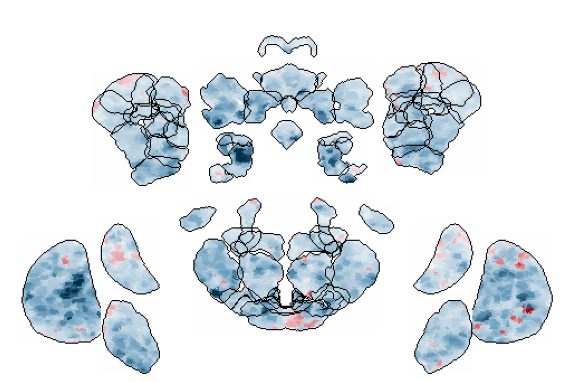

In [19]:
save_dir=os.path.join(later_dir,'figs')
plt.subplots(figsize=(10,10));
# plt.imshow(explosions[40][170:,:]) #this was made with cmap=hot
plt.imshow(explosion_map[170:,:]);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'explode_{t}_{be}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'explode_{t}_{be}_{event}.png'), dpi=300, bbox_inches='tight')

In [20]:
one='inc'
two='flat'
diff=supervox_dict_total[one]-supervox_dict_total[two]
diff=np.moveaxis(diff,-1,0)
diff_fullres=brainsss.supervoxel_to_full_res(diff, giant_cluster_labels,n_vox)

In [21]:
diff_fullres.shape

(24, 91, 314, 146)

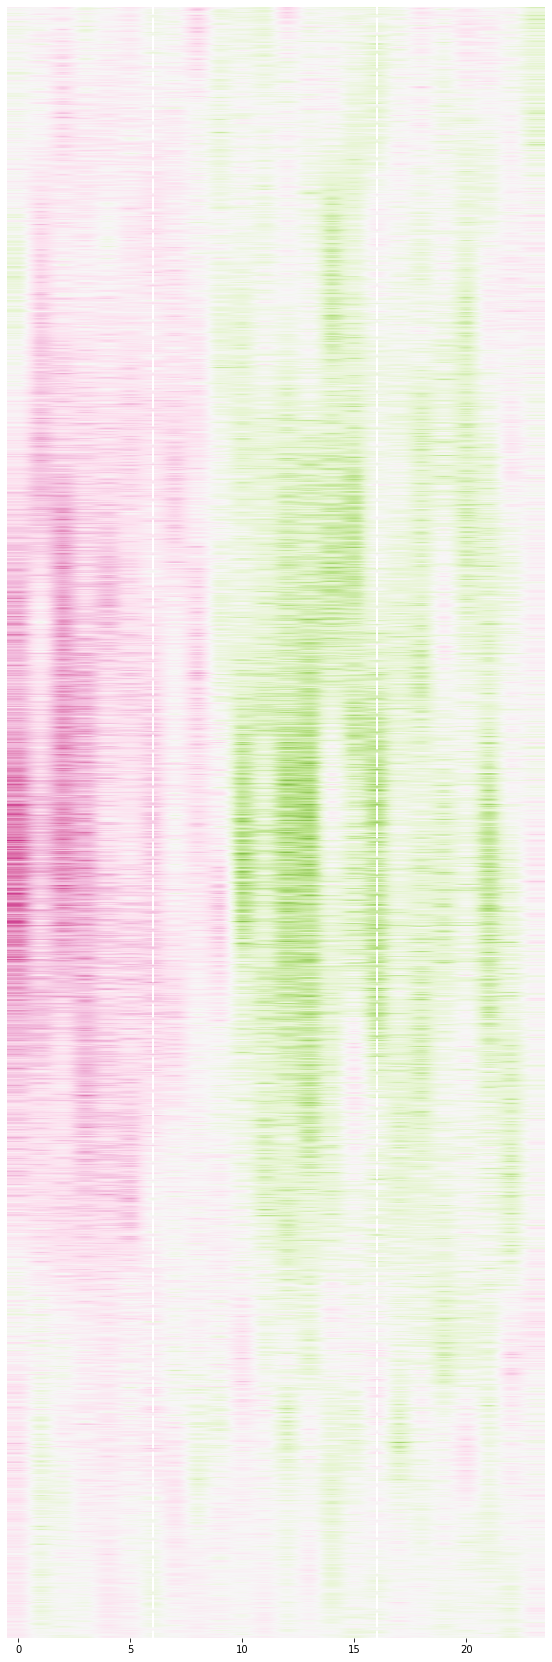

In [22]:
diff=supervox_dict_total[one]-supervox_dict_total[two]
# data=gaussian_filter(diff, sigma=1)
# data=supervox_dict[be]
vmax=0.03
vmin=-0.03
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(data)
# mycmap = matplotlib.cm.get_cmap('magma')
# final = mycmap(final)
num_areas=np.shape(diff)[0]
fig = plt.figure(figsize=(10,30))
gs = fig.add_gridspec(nrows=num_areas, ncols=1, hspace=0)
axs = gs.subplots(sharex='col', sharey=False)
for i in range(num_areas):
    img=axs[i].imshow(diff[i], cmap='PiYG', vmax=vmax, vmin=vmin)
    axs[i].set_yticks([])
    #     axs[i].set_xticks([])
    axs[i].set_aspect(0.0004)
    axs[i].axvline(x=6, ymin=0, ymax=1, ls='--', color='w', lw=2)
    axs[i].axvline(x=16, ymin=0, ymax=1, ls='--', color='w', lw=2)
#     axs[i].set_ylabel(f'z={i}', rotation=0, labelpad=20)
for ax in axs:
    ax.label_outer()
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'supervox_heatmap_{one}_minus_{two}.png'), dpi=300, bbox_inches='tight')

In [23]:
np.shape(full_res['inc'])

(314, 146, 91, 24)

In [24]:
event='best_5sec'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
    print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event in file:
        cluster_files.append(file)

superclust_clusters_25000_best.pkl
superclust_clusters_25000_flat.pkl
superclust_clusters_500_flat.pkl
superclust_clusters_flat.pkl
superclust_labels_flat.pkl
superclust_clusters_50000_flat.pkl
individual_fly_superclusters_2bin.pkl
cluster_labels_best_flies_nomask.npy
superclust_labels_best.pkl
individual_fly_superclusters_2bin_total.pkl
superclust_clusters_500_10flies_5sec.pkl
best_flies_giant_tf.npy
superclust_labels_50000_best.pkl
cluster_labels_best_flies.npy
superclust_clusters_50000_best.pkl
joblib
superclust_labels_25000_best.pkl
superclust_labels_5000_best.pkl
superclust_clusters_10flies.pkl
superclust_labels_500_best.pkl
giant_tf_test.h5
superclust_clusters_500_best_5sec.pkl
cluster_labels_208_234.npy
test_giant_tf.npy
superclust_clusters_5000_flat.pkl
superclust_labels_50000_flat.pkl
superclust_clusters_500_best.pkl
superclust_labels_10flies.pkl
superclust_labels_500_flat.pkl
superclust_labels_5000_flat.pkl
superclust_clusters_5000_best.pkl
individual_fly_superclusters.pkl
su

## Load supervox

In [25]:
cluster_files

['superclust_clusters_500_best_5sec.pkl']

In [26]:
%%time
best_cluster_path=os.path.join(cluster_dir,cluster_files[0])
print(best_cluster_path)
with open(best_cluster_path, 'rb') as file:
    best_superclust = pickle.load(file)
    print(best_superclust.keys())

# with open(flat_cluster_path, 'rb') as file:
#     flat_superclust = pickle.load(file)
#     print(flat_superclust.keys())
    

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/superclust_clusters_500_best_5sec.pkl
dict_keys(['inc', 'dec', 'flat'])
CPU times: user 1.2 ms, sys: 23 µs, total: 1.22 ms
Wall time: 13.1 ms


In [27]:
# best_superclust['flat']=flat_superclust['flat']

In [28]:
label_files

['supercluster_labels_total_500.npy']

In [29]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/supercluster_labels_total_500.npy
(4171804,)
CPU times: user 214 µs, sys: 18.8 ms, total: 19 ms
Wall time: 125 ms


In [30]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(best_superclust.keys())

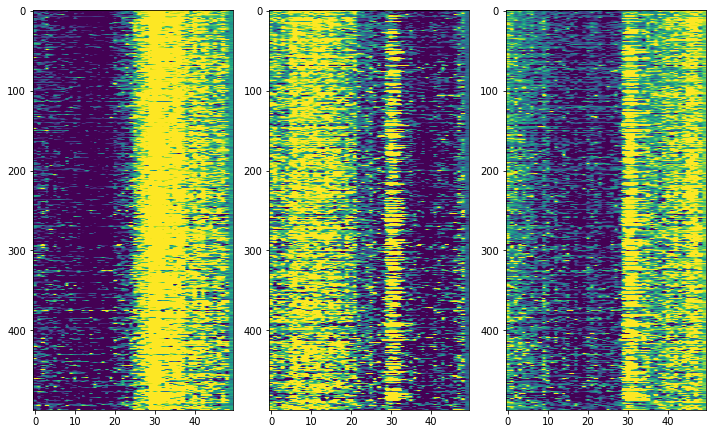

In [31]:
ax_ap=0.2
superclust_dict=best_superclust
fig,axs=plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
plt.tight_layout()

In [116]:
superclust_dict_z={}
for behavior in superclust_dict:
    print(behavior)
    signals_total_z=scipy.stats.zscore(superclust_dict[behavior][:,16:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z
    
superclust_dict_trim={}
for behavior in superclust_dict:
#     print(behavior)
    signals_total=superclust_dict[behavior][:,16:41]
    superclust_dict_trim[behavior]=signals_total

inc
dec
flat
inc
dec
flat


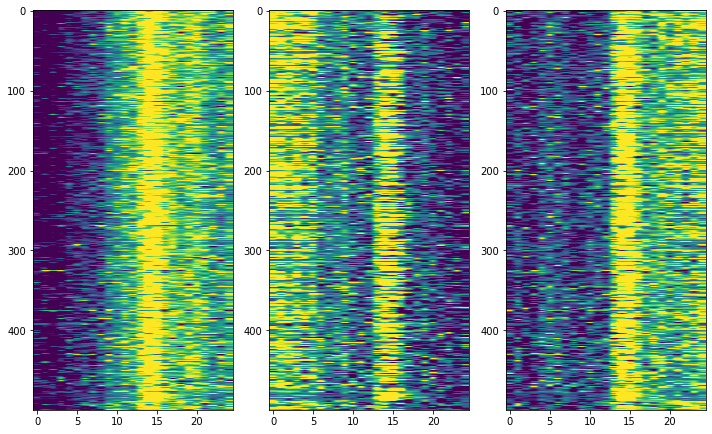

In [33]:
ax_ap=0.1
vmax=1
vmin=-1
fig,axs=plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(superclust_dict_z['inc'],vmax=vmax, vmin=vmin)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict_z['dec'],vmax=vmax, vmin=vmin)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict_z['flat'],vmax=vmax, vmin=vmin)
axs[2].set_aspect(ax_ap)
plt.tight_layout()

In [34]:
superclust_dict_z['inc'].shape

(500, 25)

In [35]:
clust_n=10
tps=[2,15]
clust_dict=superclust_dict_z
hi_low_clust={}
for tp in tps:
    hi_low_clust[tp]={}
    for be in clust_dict:
        hi_low_clust[tp][be]={}
        bef_clust=superclust_dict_z[be][:,tp]
        max_idx=np.argsort(bef_clust)[-clust_n:][::-1]
        hi_low_clust[tp][be]['max']=max_idx
        min_idx=np.argsort(bef_clust)[:clust_n]
        hi_low_clust[tp][be]['min']=min_idx

In [36]:
giant_total_labels.shape

(4171804,)

In [37]:
x,y,z,t=behave_dict_total['inc'].shape
giant_labels_anat=giant_total_labels.reshape(x,y,z)

In [117]:
%%time
full_res_superclust={}
print(n_clusters)
cluster_brain=superclust_dict_trim
for behave in behaviors:
    brain=cluster_brain[behave].T
    cluster_labels=giant_total_labels.T
    n_tp = brain.shape[0]
    n_clusters = brain.shape[1]
    brain_dims=[314,146,91]
    
    colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
    print(behave)
    colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
    colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
    colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
    full_res_superclust[behave]=np.asarray(colored_by_betas)

500
inc
dec
flat
CPU times: user 223 ms, sys: 406 ms, total: 630 ms
Wall time: 628 ms


In [118]:
full_res_superclust['inc'].shape

(25, 314, 146, 91)

In [119]:
%%time

total_vox_sorted_clust={}
for behavior in full_res_superclust:
    STA=np.moveaxis(full_res_superclust[behavior],0,-1)
    total_vox_sorted_clust[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
#             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted_clust[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted_clust[behavior][area_name]=masked_roi

CPU times: user 4.19 s, sys: 88 ms, total: 4.28 s
Wall time: 4.28 s


In [120]:
total_vox_sorted_clust['inc']['FB'].shape

(12480, 25)

In [121]:
def sort_rows_by_max_index_2(arr):
    max_indices_stim = np.nanargmax(arr, axis=1)
    sorted_order_stim = np.argsort(max_indices_stim)
    sorted_arr = arr[sorted_order_stim,:]
    return sorted_arr

In [122]:
%%time
for behavior in total_vox_sorted_clust:
    print(f'Sorting behavior {behavior}\n' 
          f'-----------------------------')
    for key in total_vox_sorted_clust[behavior]:
#         print(f'Sorting area {key}')
        total_vox_sorted_clust[behavior][key]=sort_rows_by_max_index_2(total_vox_sorted_clust[behavior][key])

Sorting behavior inc
-----------------------------
Sorting behavior dec
-----------------------------
Sorting behavior flat
-----------------------------
CPU times: user 163 ms, sys: 2 µs, total: 163 ms
Wall time: 162 ms


In [123]:
def plot_heatmap_area(areas_dict, area, ax, step_size, heights=None, vmax=0.01, vmin=-0.01,cmap='magma'):
    if step_size==10:
        stuff=np.array([[0.00006,-0.00002],[60,160]])
    elif step_size==5:
        stuff=np.array([[0.4,-0.003],[0.5,2.5]])
    elif step_size==20:
        stuff=np.array([[0.008,-0.008],[30,80]])
    elif step_size==100:
        stuff=np.array([[0.01,-0.003],[6,16]])
#     area_smooth=gaussian_filter(areas_dict[area], sigma=1.5)
    ax.imshow(areas_dict[area],vmax=vmax, vmin=vmin, cmap=cmap, interpolation='gaussian') #vmax=stuff[0,0], vmin=stuff[0,1], 
    ax.set_ylabel(area, rotation=0, labelpad=20)
    ax.axvline(x=stuff[1,0], ymin=0, ymax=1, ls='--', color='w', lw=2)
    ax.axvline(x=stuff[1,1], ymin=0, ymax=1, ls='--', color='w', lw=2)
    if heights!=None:
        median=np.median(list(heights.values()))
        if heights[area]<=median:
            ax.set_aspect(heights[area])
        else:
            ax.set_aspect('auto')
    else:
        ax.set_aspect('auto')
    ax.set_yticks([])

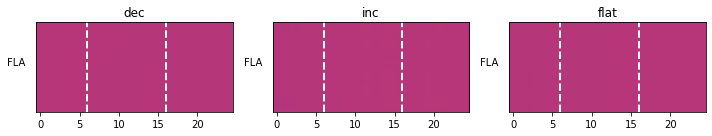

In [124]:
vmax=3
# vmax=0.03
vmin=-3
# vmin=-0.03
brain_d=total_vox_sorted_clust['dec']
brain_i=total_vox_sorted_clust['inc']
brain_f=total_vox_sorted_clust['flat']
# fig, axs = plt.subplots()
# anat='MED'
# plot_heatmap_area(brain, anat, axs, step_size, heights=heights)
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
fig, axs = plt.subplots(1,3, figsize=(10,2))
anat='FLA'
plot_heatmap_area(brain_d, anat, axs[0], step_size=100, heights=None, vmax=vmax, vmin=vmin)
axs[0].set_title('dec')
plot_heatmap_area(brain_i, anat, axs[1], step_size=100, heights=None, vmax=vmax, vmin=vmin)
axs[1].set_title('inc')
plot_heatmap_area(brain_f, anat, axs[2], step_size=100, heights=None, vmax=vmax, vmin=vmin)
axs[2].set_title('flat')
plt.tight_layout()
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [125]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=True)#'hot')
    return explosion_map

In [126]:
roi_label_dict={}
for area in explosion_rois:
    rois=explosion_rois[area]['rois']
    shifts=[explosion_rois[area]['x_shift'], explosion_rois[area]['y_shift']]
    for roi in rois:
        name=rois[roi]
        if area!=name:
            group=area
        else:
            group=name
        roi_label_dict[name]={}
        roi_label_dict[name]['label']=roi
        roi_label_dict[name]['shifts']=shifts
        roi_label_dict[name]['group']=group

In [127]:
def get_clust_num(roi, roi_label_dict,brain,roi_masks):
    lab=int(roi_label_dict[roi]['label'])
    masx = roi_masks[lab]
    masked_roi = np.where(masx==True, brain, np.nan)
    masked_roi = masked_roi[~np.isnan(masked_roi)]
    return masked_roi

In [128]:
# med_l_clusters=get_clust_num('MED_L',roi_label_dict, giant_labels_anat, roi_masks)
# med_r_clusters=get_clust_num('MED_R',roi_label_dict, giant_labels_anat, roi_masks)
# med_clusters=np.unique(np.concatenate((med_l_clusters,med_r_clusters)))
# med_clus_num=np.shape(med_clusters)
anat_1='GNG'
anat_2='FB'
clusters_1=np.unique(get_clust_num(anat_1,roi_label_dict, giant_labels_anat, roi_masks))
clus_num_1=np.shape(clusters_1)
clusters_2=np.unique(get_clust_num(anat_2,roi_label_dict, giant_labels_anat, roi_masks))
clus_num_2=np.shape(clusters_2)
x=np.concatenate((clusters_1,clusters_2))
overlapping_clusters, counts=np.unique(x, return_counts=True)
duplicates_mask=counts>1
duplicate_elements = overlapping_clusters[duplicates_mask]
print(f'{anat_1} has {clus_num_1} clusters and {anat_2} has {clus_num_2} clusters. There are {duplicate_elements.shape} overlapping clusters')

GNG has (35,) clusters and FB has (27,) clusters. There are (1,) overlapping clusters


In [129]:
clusters_2

array([  1.,   4.,   9.,  11.,  12.,  13.,  30.,  58., 105., 116., 123.,
       146., 147., 153., 167., 170., 184., 195., 214., 221., 265., 271.,
       289., 300., 350., 379., 398.])

In [130]:
duplicate_elements

array([58.])

In [131]:
giant_labels_anat_sub=np.where(giant_labels_anat==493,giant_labels_anat,np.nan)
# giant_labels_anat_sub[giant_labels_anat_sub!=0]=400

In [132]:
fixed = brainsss.load_fda_meanbrain()
brain=full_res['flat']
# smoothed=gaussian_filter(brain, sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, brain, np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

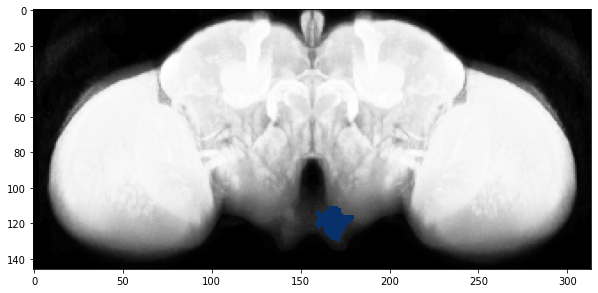

In [133]:
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(giant_labels_anat_sub,axis=-1).T,cmap='Blues_r')


In [134]:
full_res_superclust['flat'].shape

(25, 314, 146, 91)

In [144]:
tp=2
vmax=0.05
ex_f=explode_plot(full_res_superclust['flat'],vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
ex_i=explode_plot(full_res_superclust['inc'],vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
ex_d=explode_plot(full_res_superclust['dec'],vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)


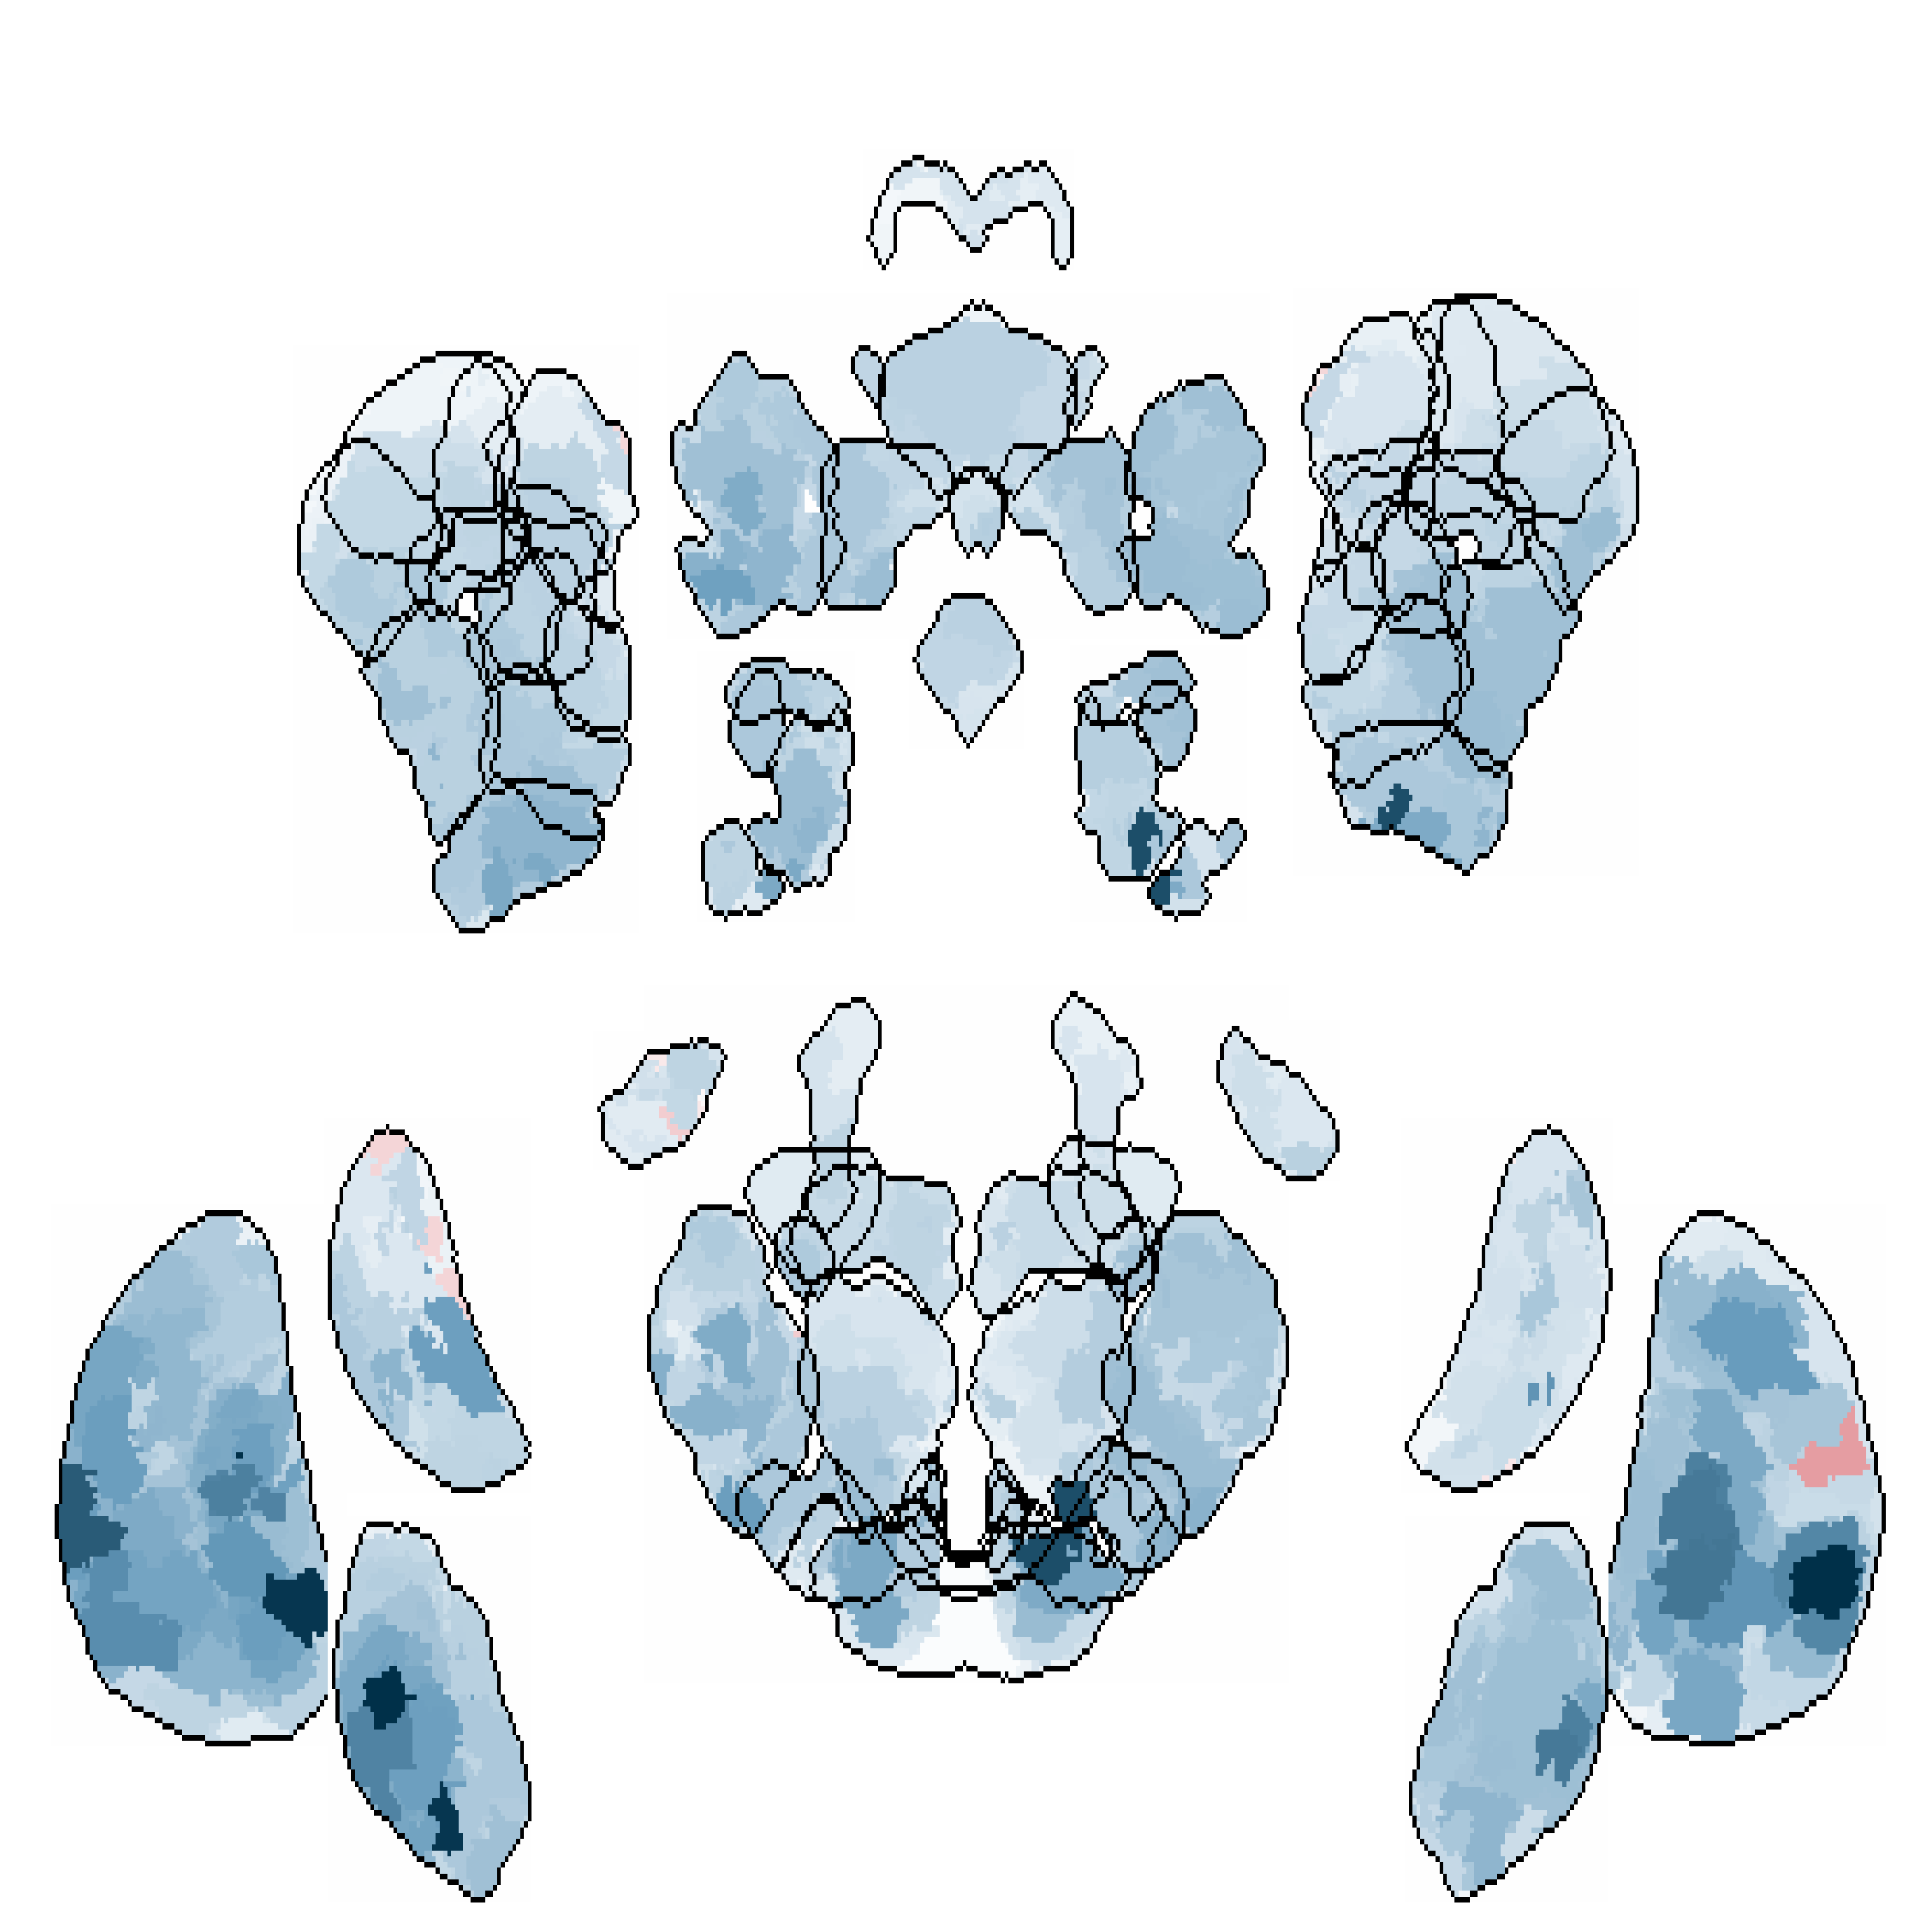

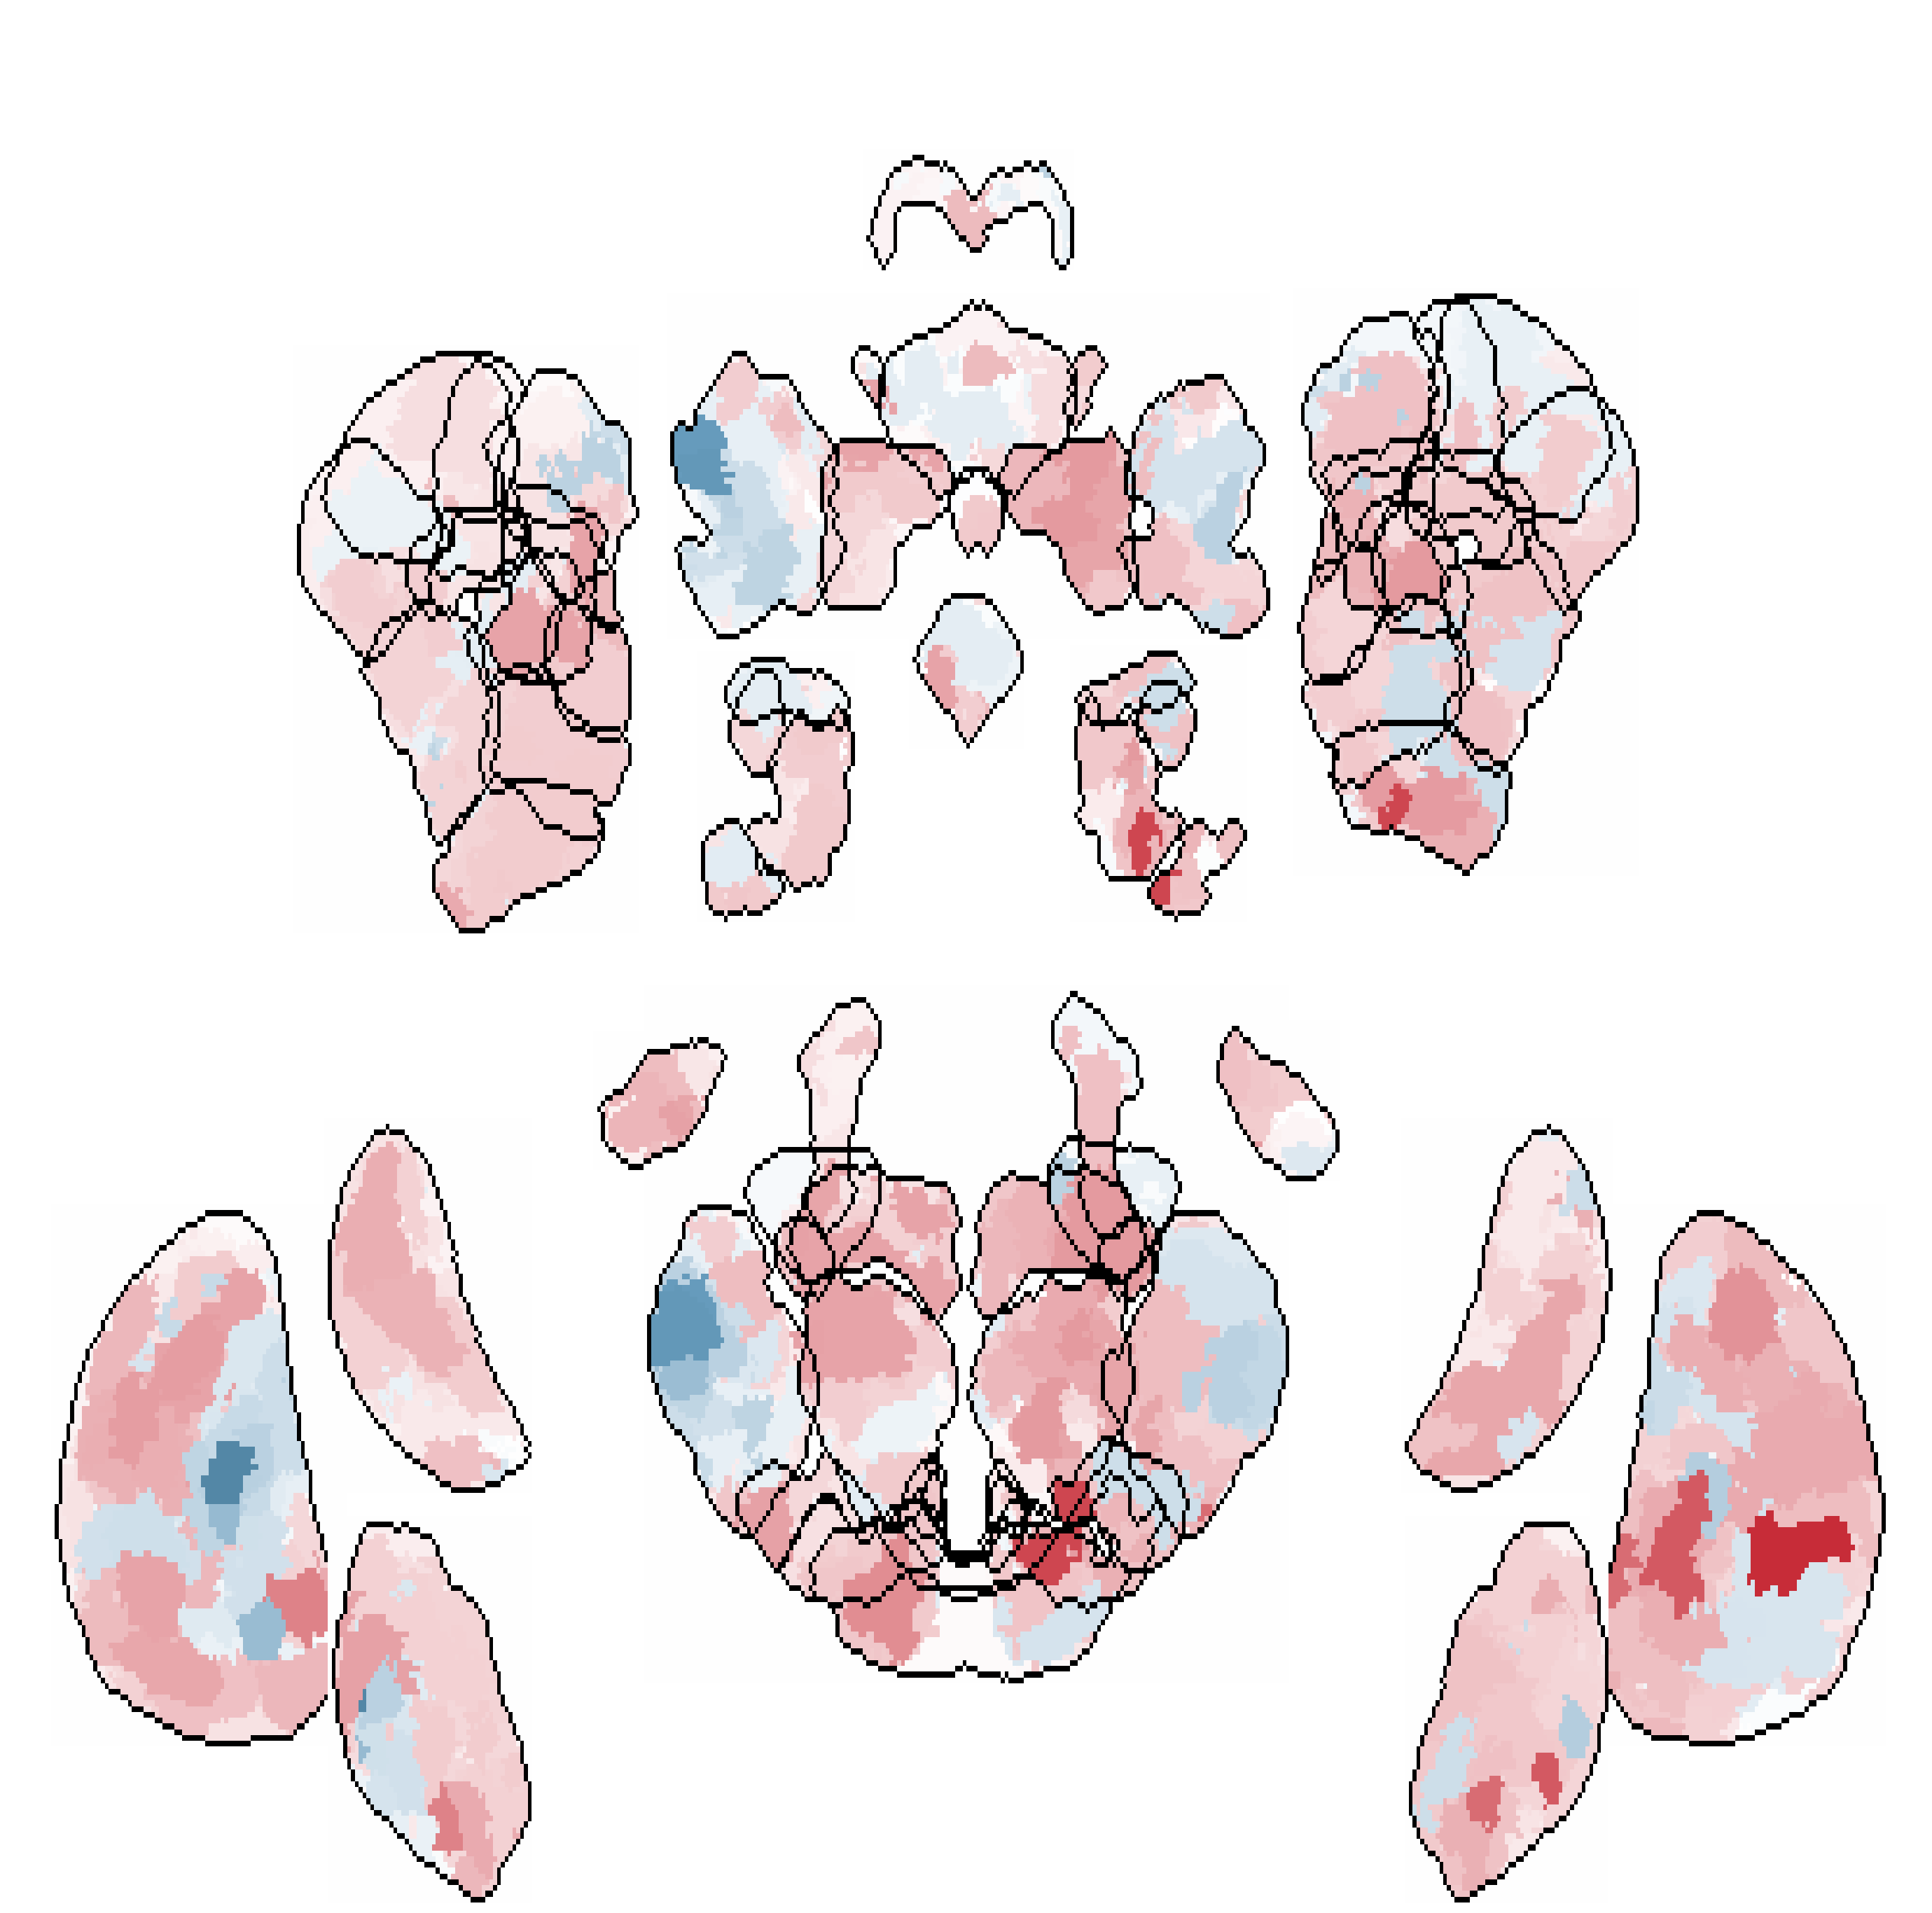

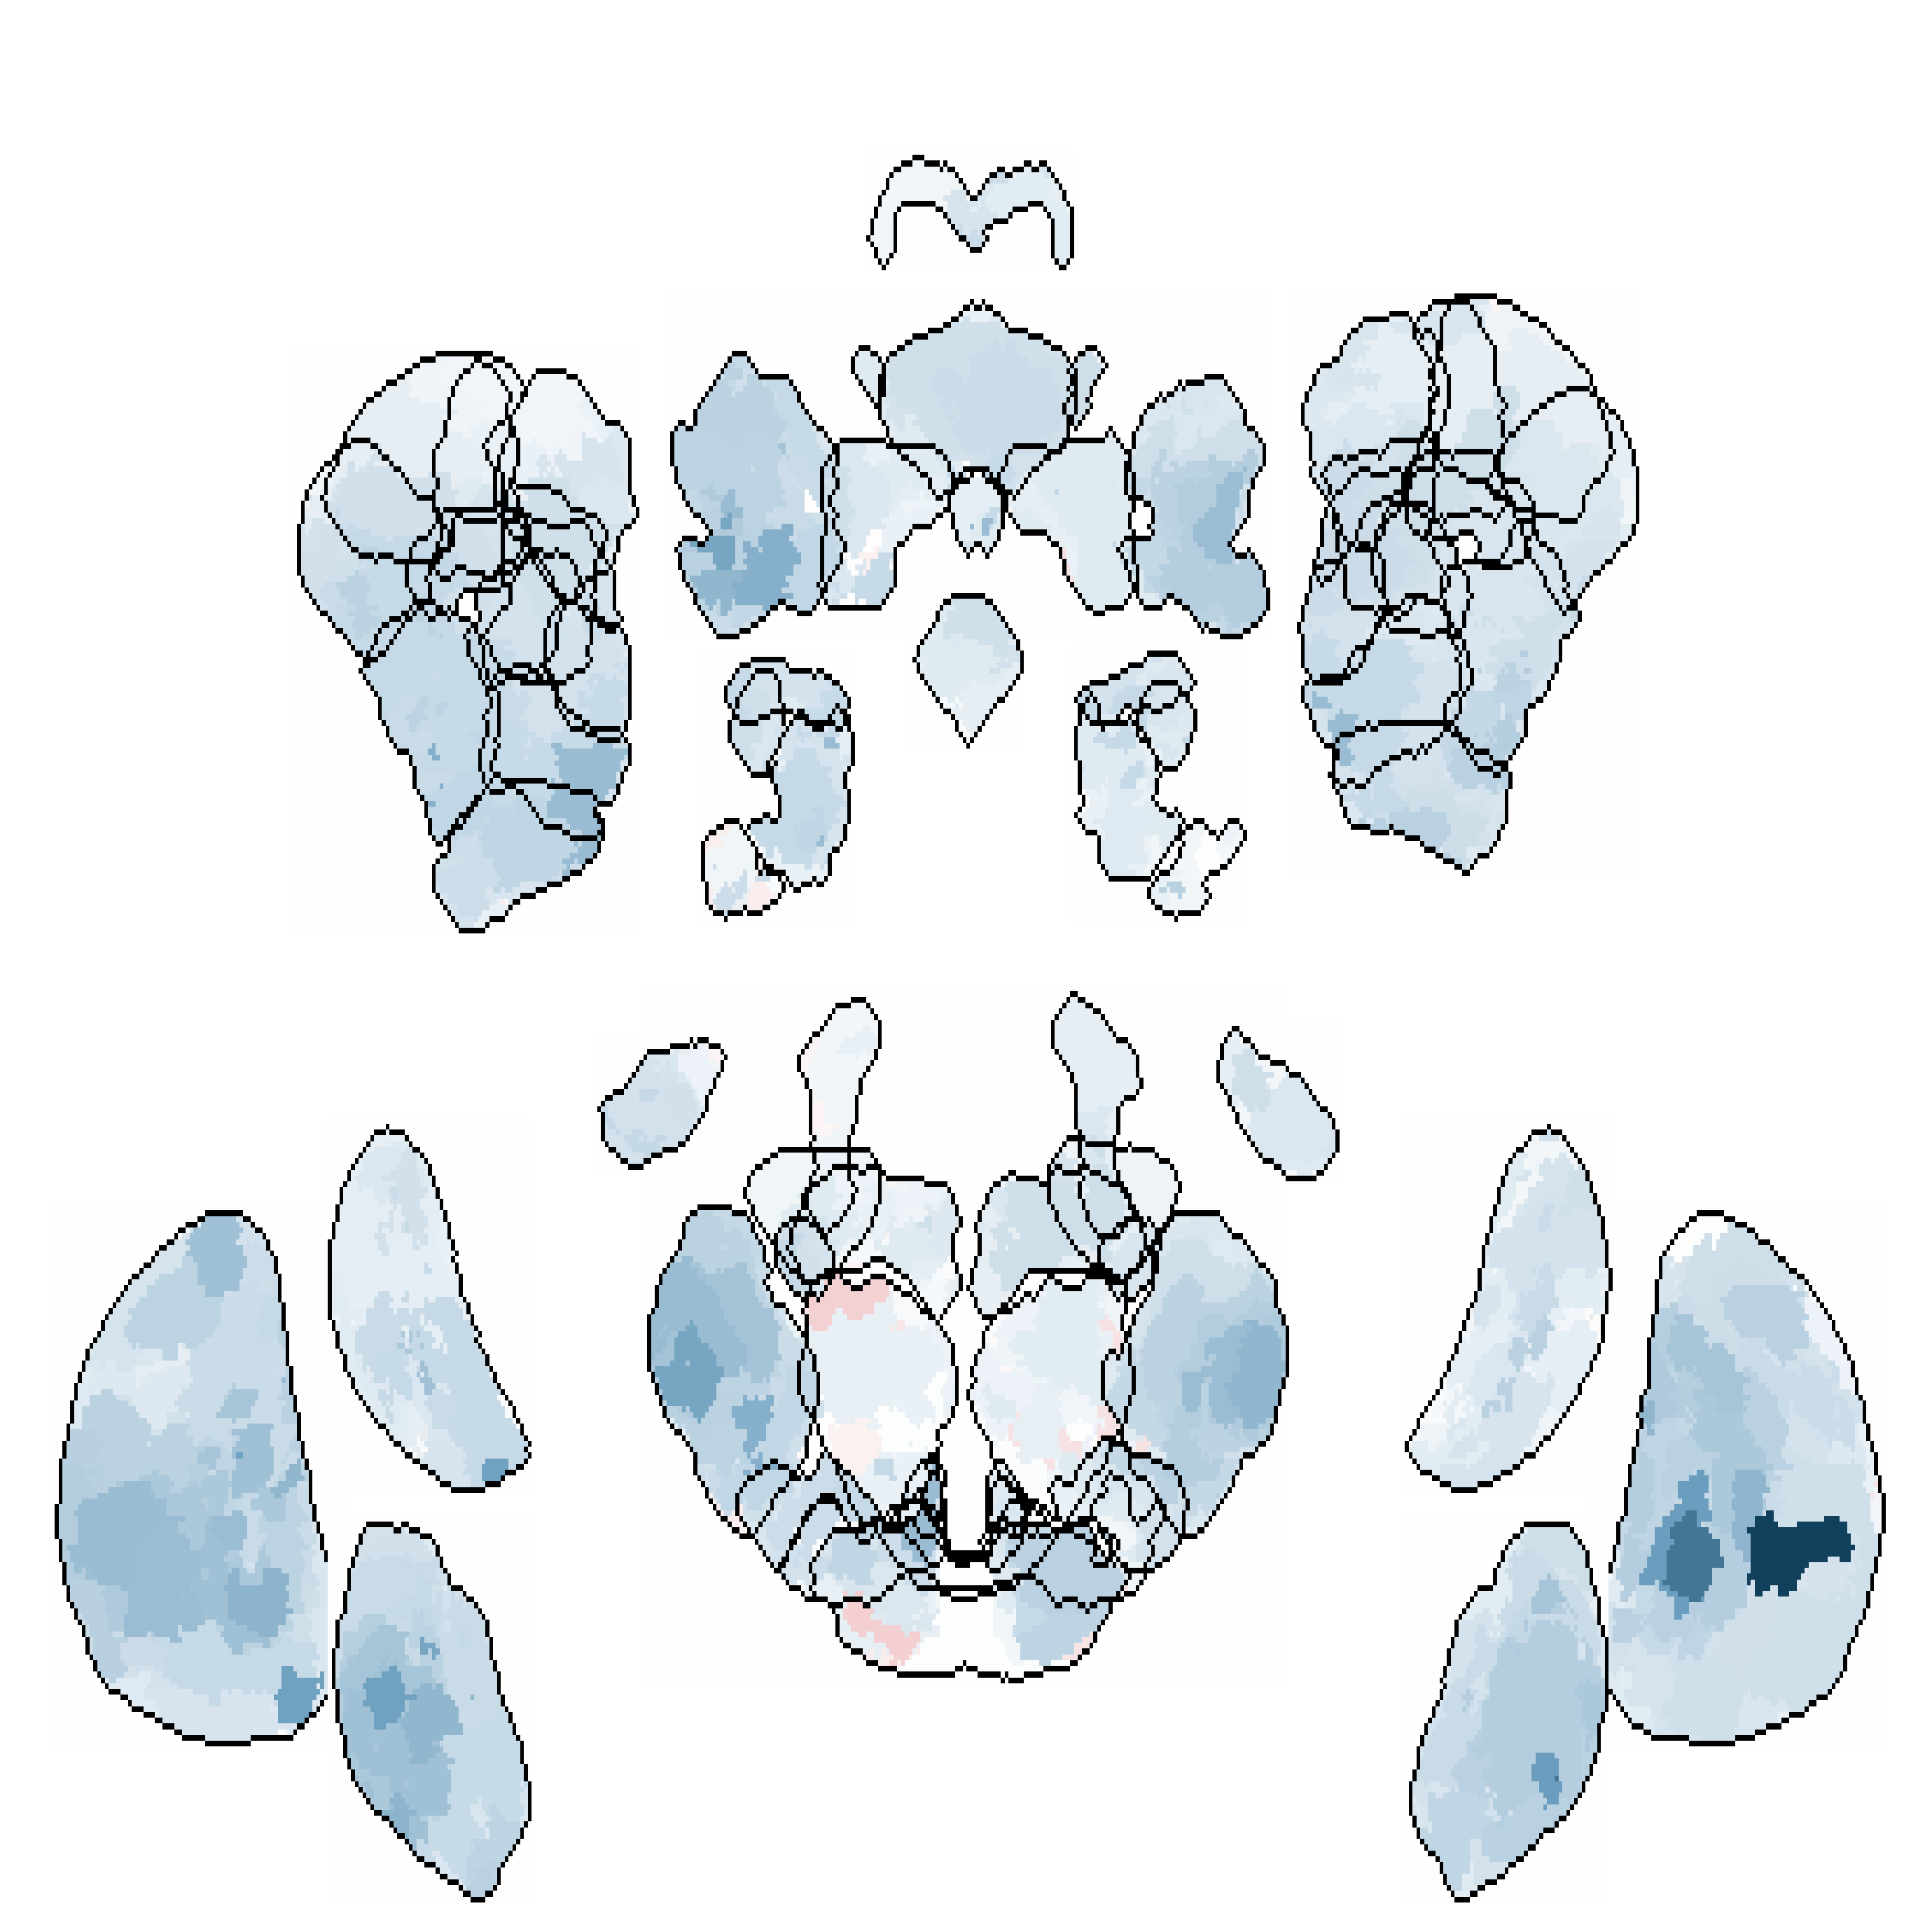

In [145]:
ax_as=1.5
fig,axs=plt.subplots(figsize=(50,50))
axs.imshow(ex_i[170:,:]) #this was made with cmap=hot
axs.axis('off')
# axs.set_title('inc',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explode_{tp}_inc.png'), dpi=300, bbox_inches='tight', transparent=True)
fig,axs=plt.subplots(figsize=(50,50))
axs.imshow(ex_d[170:,:]) #this was made with cmap=hot
axs.axis('off')
# axs.set_title('dec',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explode_{tp}_dec.png'), dpi=300, bbox_inches='tight', transparent=True)
fig,axs=plt.subplots(figsize=(50,50))
axs.imshow(ex_f[170:,:]) #this was made with cmap=hot
axs.axis('off')
# axs.set_title('flat',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explode_{tp}_flat.png'), dpi=300, bbox_inches='tight', transparent=True)

## Trying Permutation Test

In [58]:
def euclidean_dist_permute(dic, in_dim, n_permutations=1000):

    bs=list(dic.keys())
    dims=np.shape(dic[bs[0]])
    print(dims)
    combos=list(itertools.combinations(bs, 2))
    dim=dims[in_dim]
    other_dim=dims[1-in_dim]
    
    all_permutations = np.array([np.random.permutation(other_dim) 
                                for _ in range(n_permutations)])  # Shape: (n_permutations, other_dim)
    
    dist_per_dim={}
    null_per_dim={}
    p_vals={}
    
    for c in combos:
        start,end=c[0],c[-1]
        new_key=f'{start}_vs_{end}'
        print(new_key)
        
        # Get data matrices
        start_matrix = dic[start] if in_dim == 0 else dic[start].T
        end_matrix = dic[end] if in_dim == 0 else dic[end].T
        
        # Vectorized observed distances for all dimensions
        observed_distances = np.sqrt(np.sum((start_matrix - end_matrix) ** 2, axis=1))
        
        # Ultra-fast null distance computation using advanced indexing
        null_distances_all = []
        p_values = np.zeros(dim)
        
        for val in range(dim):
            # Use pre-computed permutations to permute end vector
            end_vec = end_matrix[val, :]
            permuted_vecs = end_vec[all_permutations]  # Shape: (n_permutations, other_dim)
            # Vectorized null distances
            start_vec = start_matrix[val, :]
            null_distances = np.sqrt(np.sum((start_vec - permuted_vecs) ** 2, axis=1))
            
            p_values[val] = (null_distances >= observed_distances[val]).sum() / n_permutations
            null_distances_all.append(null_distances)
        
        dist_per_dim[new_key] = observed_distances.tolist()
        null_per_dim[new_key] = null_distances_all
        p_vals[new_key] = p_values.tolist()
    return dist_per_dim, null_per_dim, p_vals

In [59]:
%%time
dist_per_clust, null_per_clust, clust_p_vals=euclidean_dist_permute(superclust_dict, 0, n_permutations=10000)
dist_per_tp, null_per_tp, tp_p_vals=euclidean_dist_permute(superclust_dict, 1, n_permutations=10000)

(500, 50)
inc_vs_dec
inc_vs_flat
dec_vs_flat
(500, 50)
inc_vs_dec
inc_vs_flat
dec_vs_flat
CPU times: user 3.84 s, sys: 2.75 s, total: 6.58 s
Wall time: 6.56 s


In [60]:
dist_per_tp.keys()

dict_keys(['inc_vs_dec', 'inc_vs_flat', 'dec_vs_flat'])

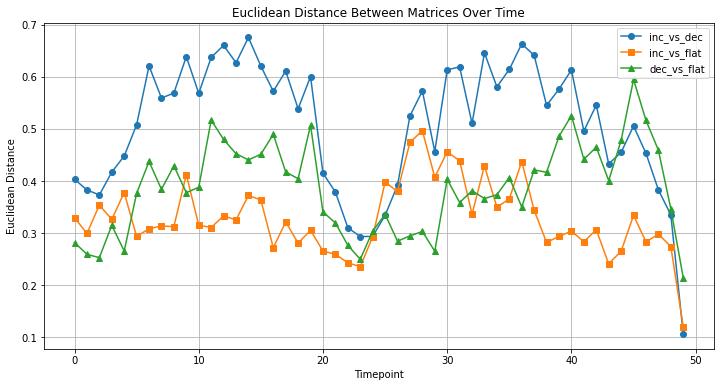

In [61]:
fig_num=len(dist_per_tp)
styles=['o-','s-','^-']
fig, axs=plt.subplots(figsize=(12,6))
for i,sub in enumerate(dist_per_tp):
    temp=dist_per_tp[sub]
    timepoints=range(np.shape(temp)[0])
    axs.plot(timepoints,temp, styles[i], label=sub)
plt.xlabel('Timepoint')
plt.ylabel('Euclidean Distance')
plt.title('Euclidean Distance Between Matrices Over Time')
plt.legend()
plt.grid(True)
plt.show()

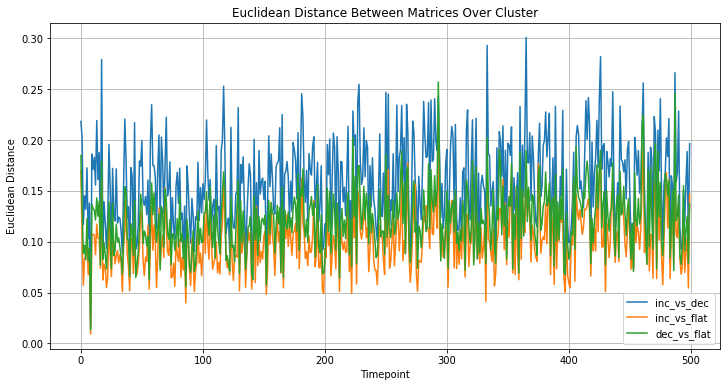

In [62]:
fig_num=len(dist_per_clust)
styles=['o-','s-','^-']
fig, axs=plt.subplots(figsize=(12,6))
for i,sub in enumerate(dist_per_clust):
    temp=dist_per_clust[sub]
    timepoints=range(np.shape(temp)[0])
    axs.plot(timepoints,temp, label=sub)
plt.xlabel('Timepoint')
plt.ylabel('Euclidean Distance')
plt.title('Euclidean Distance Between Matrices Over Cluster')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
# Apply multiple comparison correction
def comparison_correction(clust_p_vals,timepoint_p_vals):
    for comparison in clust_p_vals:
        cluster_pvals=clust_p_vals[comparison]
        timepoint_pvals=timepoint_p_vals[comparison]
        n_clusters = len(cluster_pvals)
        n_timepoints = len(timepoint_pvals)

        cluster_significant = np.array(cluster_pvals) < (0.05 / n_clusters)
        timepoint_significant = np.array(timepoint_pvals) < (0.05 / n_timepoints)

        print(f"\n{comparison}:")
        print(f"  Significant clusters: {np.sum(cluster_significant)}/{n_clusters}")
#         print(cluster_pvals)
        print(f"  Significant timepoints: {np.sum(timepoint_significant)}/{n_timepoints}")
#         print(timepoint_pvals)

        # Identify most significant clusters and timepoints
        if np.any(cluster_significant):
            sig_clusters = np.where(cluster_significant)[0]
            print(f"  Most significant clusters: {sig_clusters[:5]}")  # Top 5

        if np.any(timepoint_significant):
            sig_timepoints = np.where(timepoint_significant)[0]
            print(f"  Most significant timepoints: {sig_timepoints}")

In [64]:
comparison_correction(clust_p_vals,tp_p_vals)


inc_vs_dec:
  Significant clusters: 117/500
  Significant timepoints: 1/50
  Most significant clusters: [1 2 4 5 8]
  Most significant timepoints: [11]

inc_vs_flat:
  Significant clusters: 0/500
  Significant timepoints: 0/50

dec_vs_flat:
  Significant clusters: 6/500
  Significant timepoints: 1/50
  Most significant clusters: [ 57  62 109 132 153]
  Most significant timepoints: [12]


## Trying bootstrapping confidence intervals

In [65]:
# def euclidean_dist_bootstrap(superclust_dict, in_dim, n_bootstrap=1000):
#     bs=list(superclust_dict.keys())
#     dims=np.shape(superclust_dict[bs[0]])
#     print(dims)
#     combos=list(itertools.combinations(bs, 2))
#     superclust=superclust_dict
#     dim=dims[in_dim]
#     bootstrap_stats={}
#     dim=dims[in_dim]
#     for c in combos:
#         start=c[0]
#         end=c[-1]
#         bootstrap_stats[f'{start}_vs_{end}']={'bootstrap_distances':[],
#                                               'ci_lower':[],
#                                               'ci_upper':[],
#                                               'mean_distance':[]
#                                              }
#         for val in range(dim):
#             if in_dim==0:
#                 start_mat=superclust[start][val,:]
#                 end_mat=superclust[end][val,:]
#                 opp=1
#             else:
#                 start_mat=superclust[start][:,val]
#                 end_mat=superclust[end][:,val]
#                 opp=0

#             bootstrap_dist=[]
#             for i in range(n_bootstrap):
#                 indices = np.random.choice(dims[opp], dims[opp], replace=True)
#                 boot_mat1 = start_mat[indices]
#                 boot_mat2 = end_mat[indices]
#                 boot_distance = np.sqrt(np.sum((boot_mat1 - boot_mat2) ** 2))
#                 bootstrap_dist.append(boot_distance)
# #             print(np.shape(bootstrap_dist))

#             bootstrap_stats[f'{start}_vs_{end}']['bootstrap_distances'].append(np.array(bootstrap_dist))
#             bootstrap_stats[f'{start}_vs_{end}']['ci_lower'].append(np.percentile(bootstrap_dist, 2.5))
#             bootstrap_stats[f'{start}_vs_{end}']['ci_upper'].append(np.percentile(bootstrap_dist, 97.5)) 
#             bootstrap_stats[f'{start}_vs_{end}']['mean_distance'].append(np.mean(bootstrap_dist))
#     print(f'bootstrap dist shape:{np.shape(bootstrap_stats[f"{start}_vs_{end}"]["bootstrap_distances"])},' 
#           f'bootstrap ci lower shape:{np.shape(bootstrap_stats[f"{start}_vs_{end}"]["ci_lower"])},'
#          f'bootstrap ci upper shape:{np.shape(bootstrap_stats[f"{start}_vs_{end}"]["ci_upper"])},'
#          f'bootstrap mean_distance shape:{np.shape(bootstrap_stats[f"{start}_vs_{end}"]["mean_distance"])},')
#     return bootstrap_stats

In [66]:
# %%time
# bootstrap_stats_clust=euclidean_dist_bootstrap(superclust_dict_z, 0, n_bootstrap=100)
# bootstrap_stats_tp=euclidean_dist_bootstrap(superclust_dict_z, 1, n_bootstrap=100)

In [67]:
# print(bootstrap_stats_clust.keys())
# print(bootstrap_stats_clust['inc_vs_dec'].keys())

In [68]:
# def bootstrap_print_output(stats_dic, side):
#     for comp in stats_dic:
#         print(f"\n{comp}:")
#         comp_dic=stats_dic[comp]
#         mean_dist=comp_dic['mean_distance']
#         ci_lower=comp_dic['ci_lower']
#         ci_upper=comp_dic['ci_upper']
#         top = np.argsort(mean_dist)[-5:]  # Top 5 most different
#         print(f"Top 5 most different {side}: {top}")
#         for i,t in enumerate(top):
#             result=top[i]
#             print(f"{side} {t}: {mean_dist[t]:.3f} "
#                   f"[{ci_lower[t]:.3f}, {ci_upper[t]:.3f}]")

In [69]:
# bootstrap_print_output(bootstrap_stats_clust,'clusters')

In [70]:
# bootstrap_print_output(bootstrap_stats_tp,'time points')

In [71]:
superclust_dict_z.keys()

dict_keys(['inc', 'dec', 'flat'])

In [72]:
def make_cdf(X, x, comps):
    # estimate probability density function (pdf)
    model = GaussianMixture(n_components=comps)
    model.fit(X)
    logprob = model.score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    # derive cumulative distribution function (cdf)
    cdf = np.cumsum(pdf)
    # scale as a probability distribution
    cdf = cdf / np.max(cdf)
    return cdf,pdf

In [73]:
colors_dic={
    'inc': '#A2142F',
    'dec': '#727272',
    'flat': 'k'
}

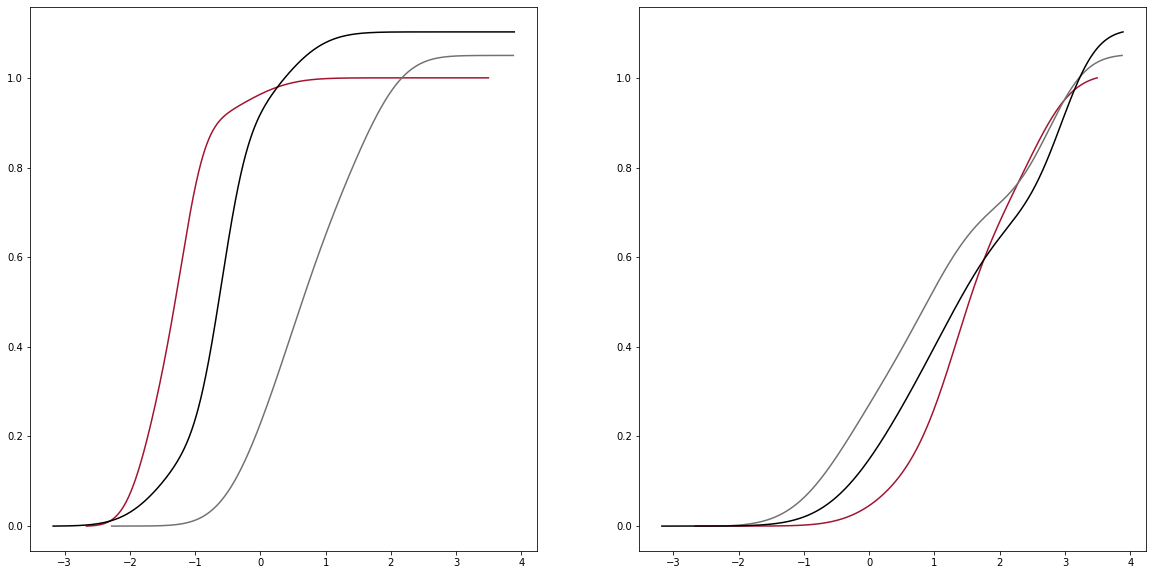

In [74]:
dic=superclust_dict_z
fig,axs=plt.subplots(1,2,figsize=(20,10))
cdf_vals={'inc':{},'dec':{},'flat':{}}
for i,be in enumerate(dic):
    Xb=dic[be][:,1].reshape(-1, 1)
    Xd=dic[be][:,14].reshape(-1, 1)
    valb, edgesb=np.histogram(Xb)
    vald, edgesd=np.histogram(Xd)
    all_edges=[edgesb.max(), edgesb.min(), edgesd.max(), edgesd.min()]
    total_max=np.max(all_edges)
    total_min=np.min(all_edges)
    x = np.linspace(total_min, total_max, 1000)
    cdfb, pdfb=make_cdf(Xb, x, 3)
    cdfd, pdfd=make_cdf(Xd, x, 3)
    
    cdf_vals[be]['before']=cdfb
    cdf_vals[be]['during']=cdfd
    
    xmin, xmax, ymin, ymax = plt.axis()
    axs[0].plot(x, cdfb * ymax, color=colors_dic[be]);
    axs[1].plot(x, cdfd * ymax, color=colors_dic[be]);
    

In [75]:
bs=list(cdf_vals.keys())
combos=list(itertools.combinations(bs, 2))
combs_dict={}
for combo in combos:
    a,b=combo
#     print(a,b)
    first=cdf_vals[a]
    second=cdf_vals[b]
    combs_dict[f'{a}_vs_{b}']={}
    for time in second:
        cdf1=first[time]
        cdf2=second[time]
        KS = np.asarray(scipy.stats.ks_2samp(cdf1, cdf2))[-1]
        print(f'{a}_vs_{b} at {time} is {KS}')
        combs_dict[f'{a}_vs_{b}'][time]=KS

inc_vs_dec at before is 2.231788601339735e-55
inc_vs_dec at during is 7.613348817400856e-28
inc_vs_flat at before is 6.977595468924532e-13
inc_vs_flat at during is 0.0038826726503625613
dec_vs_flat at before is 7.369090300875429e-16
dec_vs_flat at during is 1.2354887717127082e-13


In [76]:
dic=superclust_dict_z
ts_split_vals={'before':{},'during':{}}
for be in dic:
    print(be)
    ts_split_vals['before'][be]=dic[be][:,2].reshape(-1, 1)
    ts_split_vals['during'][be]=dic[be][:,15].reshape(-1, 1)

inc
dec
flat


In [77]:
bs=list(dic.keys())
combos=list(itertools.combinations(bs, 2))
for time in ts_split_vals:
    for c in combos:
        s,e=c
        start=ts_split_vals[time][s]
        end=ts_split_vals[time][e]
        kw_stat=stats.kruskal(start,end)
        print(f'{time} {s} vs {e} KW is: {kw_stat}')

before inc vs dec KW is: KruskalResult(statistic=655.7088656463538, pvalue=1.2810133898488931e-144)
before inc vs flat KW is: KruskalResult(statistic=159.28678801198748, pvalue=1.6198644572656864e-36)
before dec vs flat KW is: KruskalResult(statistic=454.64805837362655, pvalue=7.023941333282e-101)
during inc vs dec KW is: KruskalResult(statistic=61.25143336663268, pvalue=5.023197783595247e-15)
during inc vs flat KW is: KruskalResult(statistic=0.03970909090912755, pvalue=0.8420504499042514)
during dec vs flat KW is: KruskalResult(statistic=51.6548111568427, pvalue=6.616829716979854e-13)


In [78]:
bs=list(dic.keys())
num_clu=50
b='flat'
start=np.asarray(ts_split_vals['during'][b]).T
end=np.asarray(ts_split_vals['before'][b]).T
diff = np.abs(start-end)
p_val=scipy.stats.ttest_rel(start,end, axis=1)
sort_clust=np.argsort(diff)
bottom_clust=sort_clust[:,:num_clu][0]
top_clust=sort_clust[:,-num_clu:][0]
print(f'{b} \n most changed clust: {top_clust}\n least chnaged clust: {bottom_clust}.\n p-val: {p_val[-1]}')

flat 
 most changed clust: [ 91 241  53 448 157 417 118  75  25  26 163 323 203 360 488 257 155 370
 401 434 479 218 408 303 482 142 139 256  51 336 160 149 223 181 425 415
 354 334 429 250 291 344 179 475 208 100  55 227  61 246]
 least chnaged clust: [219 356   9 271 231 153  42 437 385 205  47 392 272 375  71  99 473 127
 126 431 438 293 285 414 184 459  98 300  43  87 342 123 148 170 120 135
  74 416  36 466 489 453 325  89 217 152   2 403 477 407].
 p-val: [2.15391651e-153]


In [79]:
start=np.asarray(ts_split_vals['during'][b]).T
end=np.asarray(ts_split_vals['before'][b]).T
diff = start-end

In [80]:
clus_num=166
diff.T[clus_num]

array([2.82677145])

In [81]:
giant_labels_anat_sub=np.where(giant_labels_anat==clus_num,giant_labels_anat,np.nan)
giant_labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_clust) ,giant_labels_anat,np.nan)       
# giant_labels_anat_sub[giant_labels_anat_sub!=0]=400

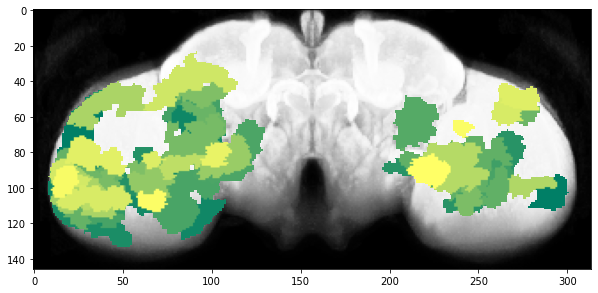

In [82]:
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(giant_labels_anat_sub_total,axis=-1).T,cmap='summer')


In [83]:
fixed = brainsss.load_fda_meanbrain()
brain=full_res_superclust[b]
masked_nonan=np.where(np.isin(giant_labels_anat,top_clust),brain, np.nan)
masked_nonan=np.nan_to_num(masked_nonan)

In [84]:
tp=14
vmax=5
during=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
tp=1
before=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)


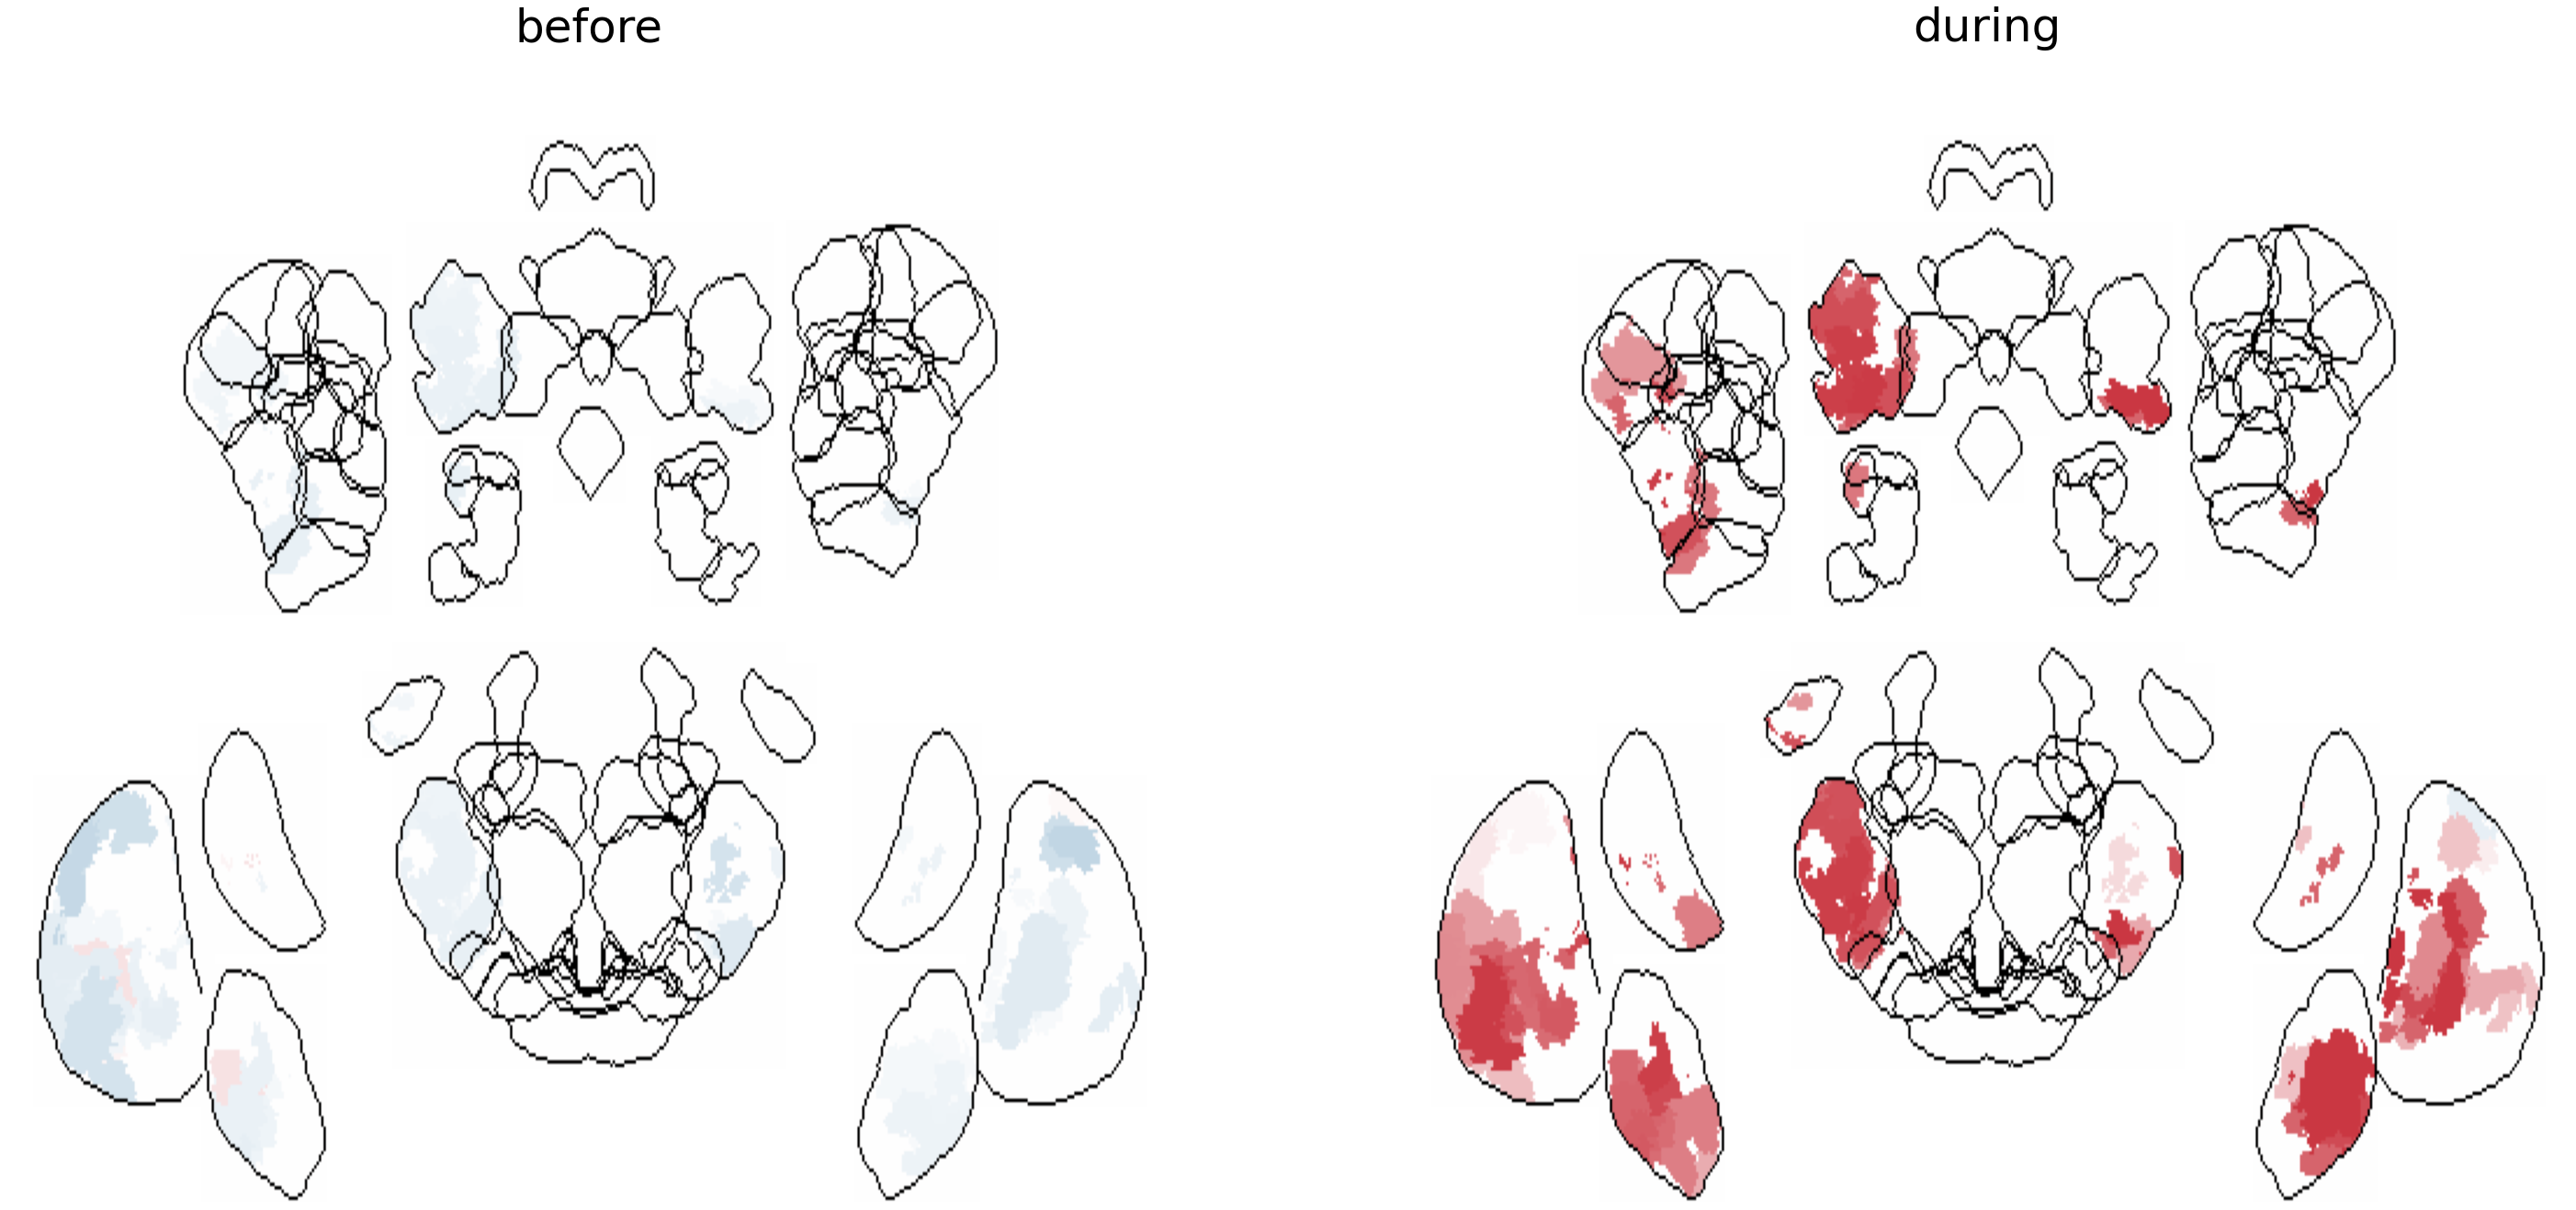

In [85]:
ax_as=1.5
fig,axs=plt.subplots(1,2,figsize=(50,50))
axs[0].imshow(before[170:,:]) #this was made with cmap=hot
axs[0].axis('off')
axs[0].set_title('before',fontsize=50)
axs[0].set_aspect(ax_as)
axs[1].imshow(during[170:,:]) #this was made with cmap=hot
axs[1].axis('off')
axs[1].set_title('during',fontsize=50)
axs[1].set_aspect(ax_as)

In [150]:
file_path=os.path.join(cluster_dir, 'individual_fly_superclusters_2bin.pkl')
with open(file_path, 'rb') as file:
        fly_superclust_dict = pickle.load(file)

In [152]:
fly_num=[226,227,228,234,239,240,241,242,249,250]
for fn in fly_num:
    behave_dic=fly_superclust_dict['flat']
    if fn in list(behave_dic.keys()):
        print(np.count_nonzero(~np.isnan(behave_dic[fn][...,-1])))

3008
68010
17432
27310
2142
1225
5659
10354
42997
46355


In [153]:
fly_superclust_dict['inc'].keys()

dict_keys([226, 227, 228, 234, 239, 240, 241, 242, 249, 250])

In [154]:
num_vox=[]
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        num_vox.append(count_vox)
max_val=np.max(num_vox)
print(max_val)

1284


In [155]:
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        if count_vox<max_val:
            pad_val=max_val-count_vox
#             print(pad_val)
            matrix=fly_superclust_dict[behave][fly]
            padded_matrix = np.pad(matrix, ((0, 0), (0, pad_val),(0,0)),'constant', constant_values=np.nan)
            fly_superclust_dict[behave][fly]=padded_matrix 

In [156]:
fly_superclust_dict['inc'][226].shape

(500, 1284, 2)

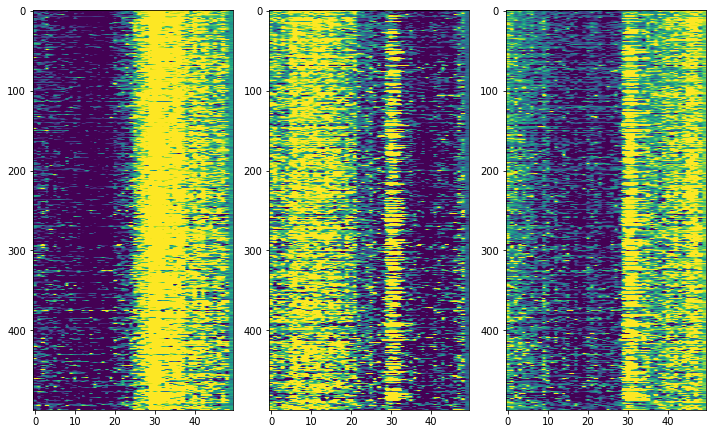

In [157]:
ax_ap=0.2
superclust_dict=best_superclust
fig,axs=plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
plt.tight_layout()

In [158]:
superclust_dict_z['inc'].shape

(500, 25)

In [94]:
bin_size=5
downsampled_superclust_dict={}
clust_dict=superclust_dict_z
for behave in clust_dict:
    num_bins=int((clust_dict[behave].shape[-1]+1)/bin_size)
    start=0
    downsampled_superclust=[]
    for i in range(num_bins):
        end=start+bin_size
#         print(start,end)
        avg_time=np.mean(clust_dict[behave][:,start:end],axis=-1)
        downsampled_superclust.append(avg_time)
        start=end
    downsampled_superclust=np.asarray(downsampled_superclust).T
#     print(np.shape(downsampled_superclust))
    downsampled_superclust_dict[behave]=downsampled_superclust

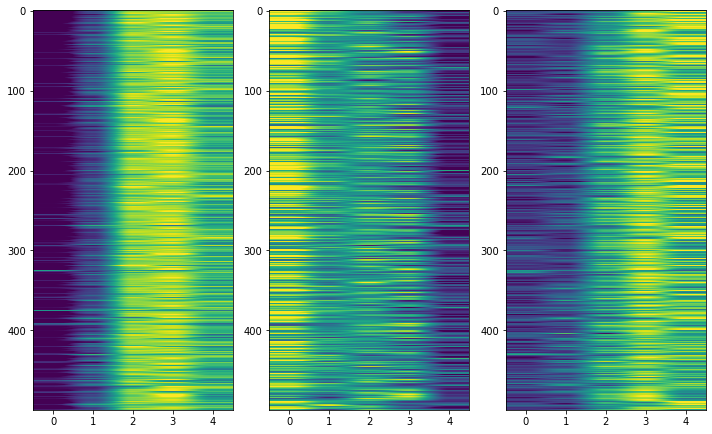

In [95]:
ax_ap=0.02
vmax=1
vmin=-1
fig,axs=plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(downsampled_superclust_dict['inc'], vmax=vmax,vmin=vmin)
axs[0].set_aspect(ax_ap)
axs[1].imshow(downsampled_superclust_dict['dec'],  vmax=vmax,vmin=vmin)
axs[1].set_aspect(ax_ap)
axs[2].imshow(downsampled_superclust_dict['flat'],  vmax=vmax,vmin=vmin)
axs[2].set_aspect(ax_ap)
plt.tight_layout()

In [96]:
downsampled_superclust_dict_z={}
for behavior in downsampled_superclust_dict:
    print(behavior)
    signals_total_z=scipy.stats.zscore(downsampled_superclust_dict[behavior],axis=1)
    downsampled_superclust_dict_z[behavior]=signals_total_z

inc
dec
flat


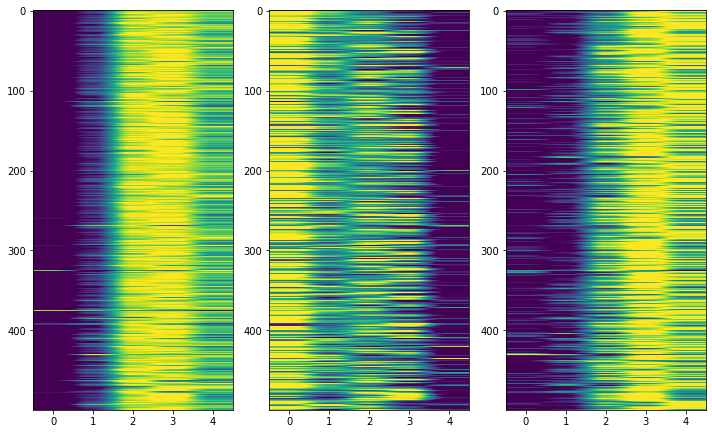

In [97]:
vmax=1
vmin=-1
ax_ap=0.02
fig,axs=plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(downsampled_superclust_dict_z['inc'], vmax=vmax,vmin=vmin)
axs[0].set_aspect(ax_ap)
axs[1].imshow(downsampled_superclust_dict_z['dec'],  vmax=vmax,vmin=vmin)
axs[1].set_aspect(ax_ap)
axs[2].imshow(downsampled_superclust_dict_z['flat'],  vmax=vmax,vmin=vmin)
axs[2].set_aspect(ax_ap)
plt.tight_layout()

In [98]:
%%time
downsampled_full_res_superclust={}
print(n_clusters)
cluster_brain=downsampled_superclust_dict
for behave in behaviors:
    brain=cluster_brain[behave].T
    cluster_labels=giant_total_labels.T
    n_tp = brain.shape[0]
    n_clusters = brain.shape[1]
    brain_dims=[314,146,91]
    
    colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
    print(behave)
    colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
    colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
    colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
    downsampled_full_res_superclust[behave]=np.asarray(colored_by_betas)

500
inc
dec
flat
CPU times: user 138 ms, sys: 74 ms, total: 212 ms
Wall time: 211 ms


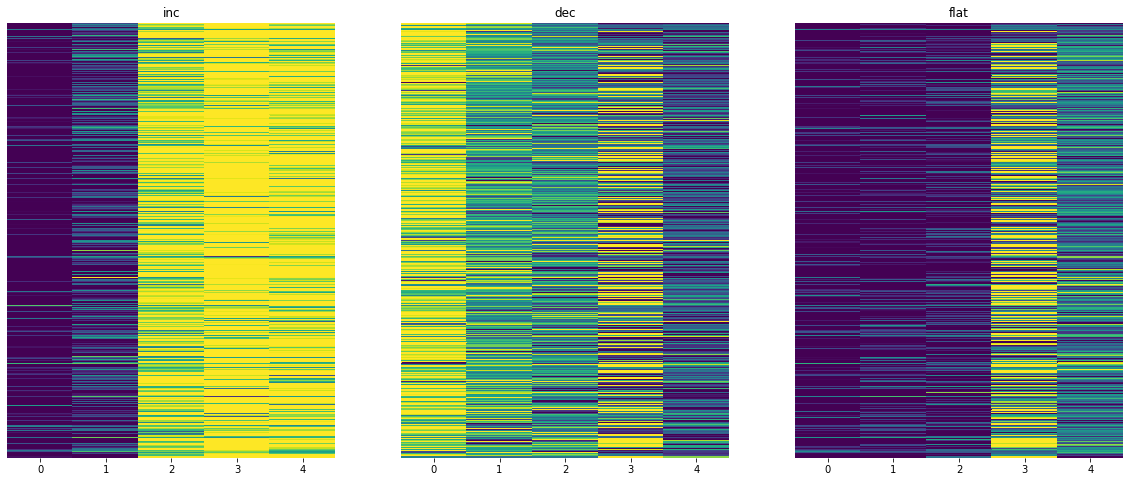

In [99]:
fig,axs=plt.subplots(1,3,figsize=(20,8))
for i,be in enumerate(fly_superclust_dict):
    avg=[]
    for fly in fly_superclust_dict[be]:
#         print(fly)
        superclusts=np.nanmean(fly_superclust_dict[be][fly],axis=-2)
        superclusts=np.nan_to_num(superclusts)
        avg.append(superclusts)
#     print(np.shape(avg))
    avg=np.mean(avg,axis=0)
    sns.heatmap(avg, cmap='viridis', cbar=False,ax=axs[i],yticklabels=False,vmax=0.01,vmin=-0.01)
    axs[i].set_title(be)
    axs[i].set_title(be)

# ax_ap=0.02
# fig,axs=plt.subplots(1,3,figsize=(10,8))
# for i,be in enumerate(fly_superclust_dict):
#     avg=np.zeros_like(downsampled_superclust_dict['inc'])
#     for fly in fly_superclust_dict[be]:
# #         print(fly)
#         superclusts=np.nanmean(fly_superclust_dict[be][fly],axis=-2)
#         superclusts=np.nan_to_num(superclusts)
#         avg+=superclusts
#     num_flies=np.shape(list(fly_superclust_dict[be].keys()))[0]
#     avg=avg/num_flies
#     axs[i].imshow(avg, cmap='viridis',vmax=0.01,vmin=-0.01)
#     axs[i].set_aspect(ax_ap)
#     axs[i].set_title(be)

In [100]:
top_indicies_all=[57,13,132,48]

In [101]:
be='inc'
top_clus_dict={}

for clus in top_indicies_all:
    top_clus_dict[clus]=[]
    for fly in fly_superclust_dict[be]:
        vox_vals=fly_superclust_dict[be][fly][clus]
        vox_vals=vox_vals[~np.isnan(vox_vals)]
        top_clus_dict[clus].append(vox_vals)
        
    top_clus_dict[clus]=np.hstack(top_clus_dict[clus])
    print(np.shape(top_clus_dict[clus]))

(416,)
(474,)
(432,)
(432,)


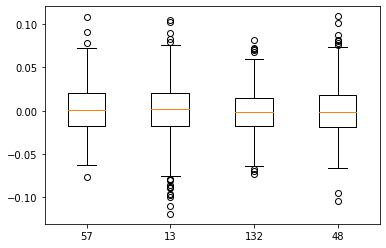

In [102]:
plt.boxplot(top_clus_dict.values(), labels=top_clus_dict.keys())
plt.show()

In [103]:
%%time
anova_dict={}
for behave in fly_superclust_dict:
    anova_dict[behave]={}
    avg_clusts=downsampled_superclust_dict[behave]
    individual_clusts=fly_superclust_dict[behave]
    for i,super_clust in enumerate(avg_clusts):
        anova_dict[behave][i]=[]
        for v, tp in enumerate(super_clust):
            ind_clus=[]
            for fly in individual_clusts:
                ind_clus_nan=individual_clusts[fly][i,:,v]
#                 print(ind_clus_nan)
#                 if np.all(np.isnan(ind_clus_nan))==False:
                ind_clus=np.concatenate((ind_clus,ind_clus_nan))

            anova_dict[behave][i].append(np.asarray(ind_clus))
        anova_dict[behave][i]=np.asarray(anova_dict[behave][i])
#         print(np.shape(anova_dict[behave][i]))

CPU times: user 246 ms, sys: 67.1 ms, total: 313 ms
Wall time: 313 ms


In [104]:
anova_dict['inc'][150].shape

(5, 6920)

In [105]:
np.count_nonzero(~np.isnan(anova_dict['flat'][499][2]))

383

In [106]:
b_1='flat'
b_2='inc'
pval_dict=[]
for clust in range(500):
    a=anova_dict[b_1][clust]
#     print(np.shape(a))
    b=anova_dict[b_2][clust]
#     print(np.shape(b))
    tstat,p_val=scipy.stats.ttest_ind(a,b,axis=-1,nan_policy='omit')
# #     print(p_val)
    pval_dict.append(list(p_val))

In [107]:
pval_flat=np.asarray(pval_dict).flatten()
rejected, p_corrected, alpha_sidak, alpha_bonf = multipletests(pval_flat, alpha=0.01, method='bonferroni')
pval_correct=p_corrected.reshape(*np.shape(pval_dict))

<AxesSubplot:>

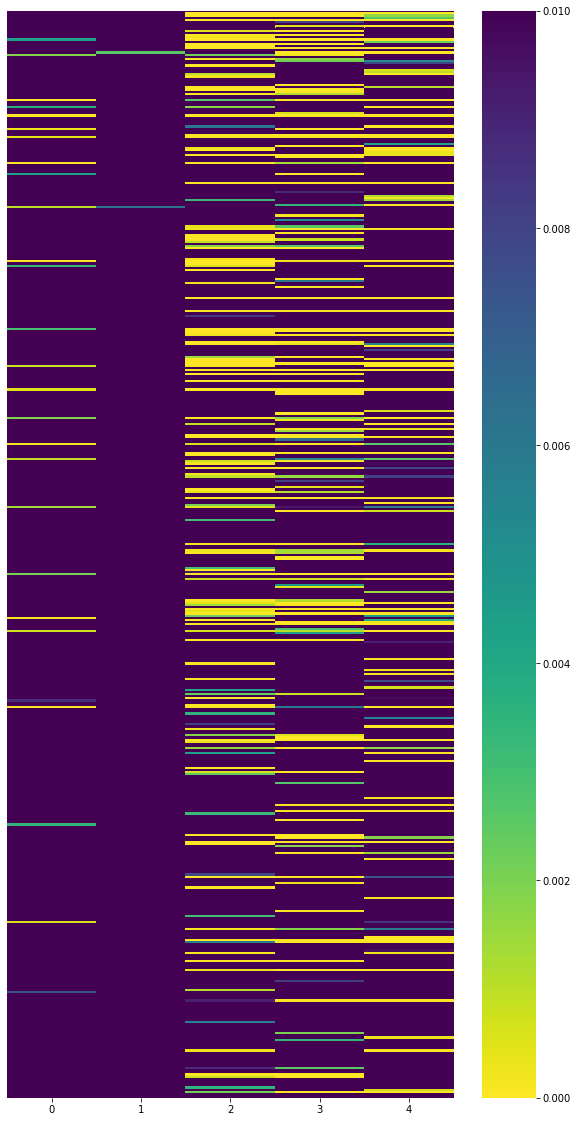

In [108]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
sns.heatmap(pval_correct, 
            cmap='viridis_r', 
            cbar=True,
            ax=ax,yticklabels=False, vmax=0.01)
# ax.axhline(y=379, color='w', lw=2)

In [109]:
pval_correct[379,:]

array([1.00000000e+00, 1.00000000e+00, 1.38739660e-12, 9.22751287e-10,
       1.00000000e+00])

In [110]:
num_clu=20
flat_indices = np.argpartition(pval_correct.flatten(), num_clu)[:num_clu]
top_indices = np.unravel_index(flat_indices, pval_correct.shape)
top_indices[0]

array([350,  57,  36, 437,  58,  13,  57, 380, 174,  57, 220, 119,  38,
        13, 259, 379, 132, 335,  48,  17])

In [111]:
bef=[144, 275, 277, 335, 339, 428]

In [112]:
tp=1
sub=pval_correct[:,tp]
interesting=np.where(sub<=0.01)[0]
interesting

array([19, 90])

In [113]:
# interesting=[i for i in bef if i in interesting]
interesting=[13,70,146,259]

In [114]:
colors={
    'inc': '#A2142F',
    'dec': '#727272',
    'flat': 'k'
}

(4,)


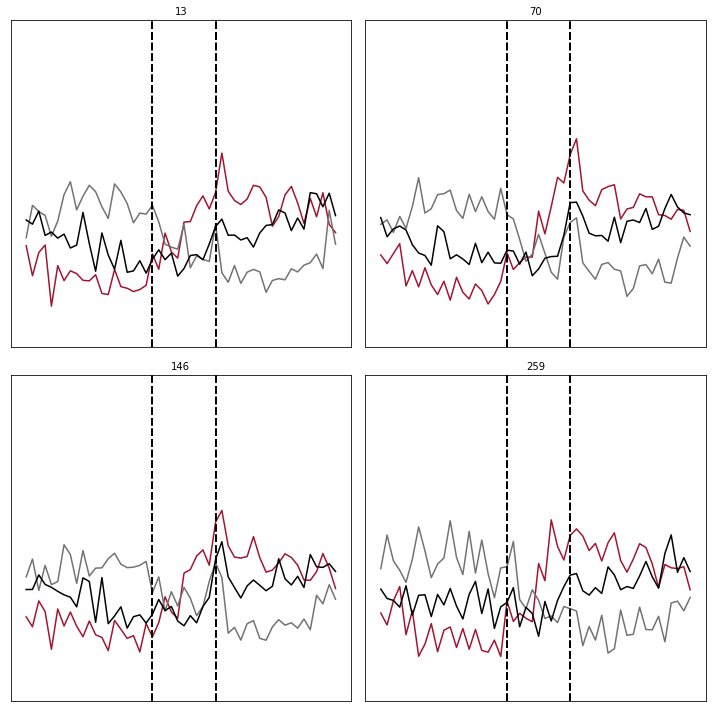

In [159]:
# clusters_4_look=np.arange(100,200)
clusters_4_look=np.asarray(interesting)
fig_shape=int(np.ceil(np.sqrt(clusters_4_look.shape)))
print(clusters_4_look.shape)
fig,axs=plt.subplots(fig_shape,fig_shape,figsize=(10,10))
axs=axs.flatten()
for behave in superclust_dict:
    for ind in range(clusters_4_look.size):
        clus=clusters_4_look[ind]
#         print(clus)
        axs[ind].plot(superclust_dict[behave][clus,:],color=colors[behave], label=behave)
        axs[ind].set_ylim(-0.05,0.1)
        axs[ind].set_xticks([])
        axs[ind].set_yticks([])
        axs[ind].set_title(clus,fontsize=10)
        axs[ind].axvline(x=20, ymin=0, ymax=1, ls='--', color='k', lw=2)
        axs[ind].axvline(x=30, ymin=0, ymax=1, ls='--', color='k', lw=2)
plt.tight_layout() 
plt.show()

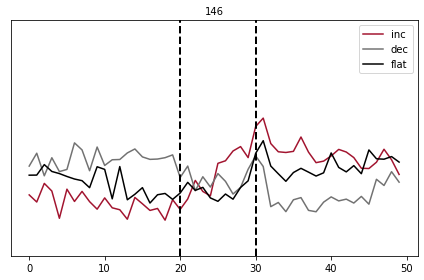

In [118]:
fig,axs=plt.subplots()
clus=146
for behave in superclust_dict:
    axs.plot(superclust_dict[behave][clus,:],color=colors[behave], label=behave)
    axs.set_ylim(-0.05,0.1)
#     axs.set_xticks([])
axs.set_yticks([])
axs.set_title(clus,fontsize=10)
axs.axvline(x=20, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=30, ymin=0, ymax=1, ls='--', color='k', lw=2)
plt.tight_layout() 
plt.legend()
plt.show()

In [119]:
%%time
clust_sizes=np.zeros(500)
for i in range(np.shape(pval_correct)[0]):
    clust_mask=giant_labels_anat[giant_labels_anat==i]
    size=int(np.count_nonzero(clust_mask))
#     print(size)
    if i!=8:
        clust_sizes[i]=size

CPU times: user 1.09 s, sys: 0 ns, total: 1.09 s
Wall time: 1.09 s


In [120]:
np.min(clust_sizes)

0.0

In [121]:
pval_correct_sub=np.where(pval_correct<0.0001,pval_correct,np.nan)

In [122]:
clus_where,time_where=np.where(~np.isnan(pval_correct_sub))
earliest=np.argsort(time_where)[:5]
early_clus=clus_where[earliest]
early_clus

array([320, 115,  48,  41,  70])

In [123]:
clust_sizes[interesting]

array([7608., 7313., 6052., 3414.])

Text(0.5, 0, 'size of cluster by vox count')

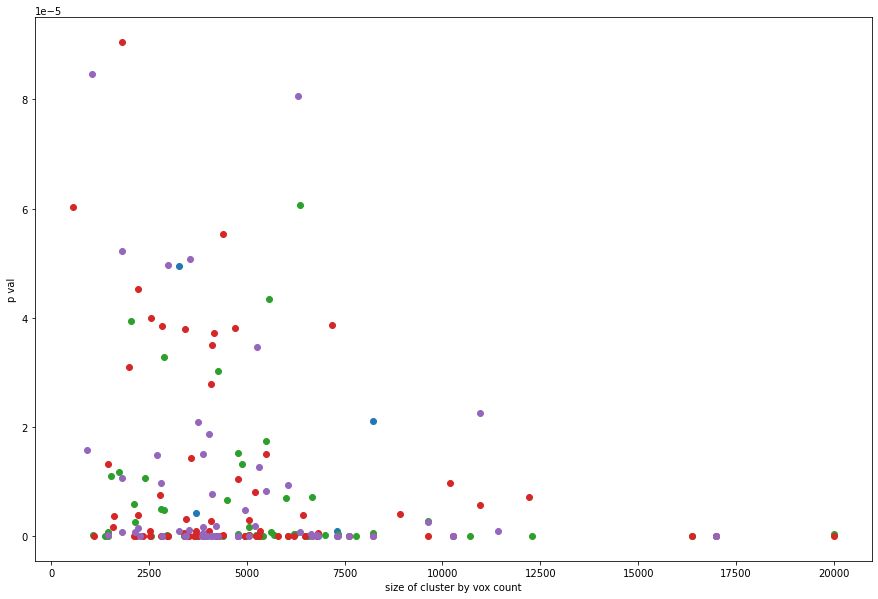

In [124]:
fig,axs=plt.subplots(figsize=(15,10))

for i in range(np.shape(pval_correct)[1]):
    axs.scatter(clust_sizes,pval_correct_sub[:,i])
#     axs.annotate(i,clust_sizes,pval_correct_sub[:,i])

axs.set_ylabel('p val')
axs.set_xlabel('size of cluster by vox count')

In [125]:
top_indicies_all=[57,13,132,48]
of_interest=interesting

In [126]:
# pval_correct[top_indices]
pval_correct[interesting,:]

array([[4.43360810e-03, 1.00000000e+00, 4.98265070e-08, 3.67924896e-18,
        2.27828468e-13],
       [8.75680893e-07, 1.00000000e+00, 2.30007625e-09, 1.34738784e-03,
        1.38430941e-10],
       [2.95944649e-03, 1.00000000e+00, 2.38320947e-09, 6.73397430e-08,
        9.29008079e-06],
       [2.07668266e-03, 1.00000000e+00, 5.00792173e-15, 1.65641367e-09,
        2.32805488e-09]])

In [127]:
top_start_i=np.argsort(pval_correct[:,0])[:10]
print(top_start_i)
top_start=pval_correct[top_start_i,0]
print(top_start)

[ 41  70 115  48 320 279 199  54  58 174]
[3.93485072e-07 8.75680893e-07 4.27607954e-06 2.11583419e-05
 4.93914360e-05 1.40124113e-04 1.60141773e-04 2.48086912e-04
 3.61861249e-04 4.89116015e-04]


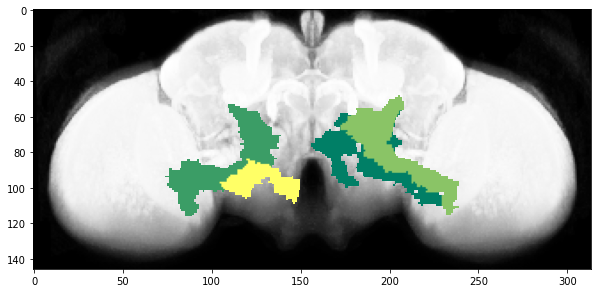

In [128]:
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,of_interest),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='summer')


In [129]:
labels_anat_sub_total[~np.isnan(labels_anat_sub_total)]

array([ 70.,  70.,  70., ..., 146., 146., 146.])

In [130]:
%%time
brain=fixed.numpy()
masked=np.where(~np.isnan(labels_anat_sub_total),brain, False)
empty=np.where(masked==False,masked, True)
full_er_r=binary_erosion(empty, structure=np.ones((1,1,1)))
full_di_r=binary_dilation(full_er_r, iterations=1)
print(np.shape(full_di_r))

(314, 146, 91)
CPU times: user 72.4 ms, sys: 28.1 ms, total: 100 ms
Wall time: 99.7 ms


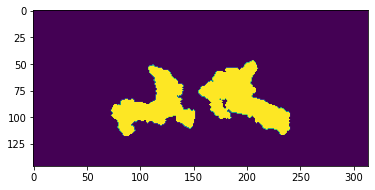

In [131]:
plt.imshow(np.max(full_di_r,axis=2).T)

In [132]:
verts_region, faces_region, _, _ = measure.marching_cubes(full_di_r, level=0.5)

In [133]:
brain=fixed.numpy()
masked=np.where(brain>0.25,brain, False)
empty=np.where(masked==False,masked, True)
full_er=binary_erosion(empty, structure=np.ones((1,1,1)))
full_di=binary_dilation(full_er, iterations=1)
print(np.shape(full_di))

(314, 146, 91)


In [134]:
np.unique(full_di)

array([False,  True])

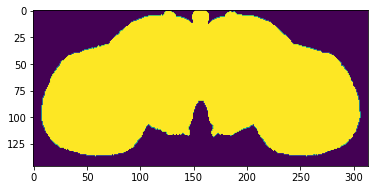

In [135]:
plt.imshow(np.max(full_di,axis=2).T)

In [136]:
verts, faces, _, _ = measure.marching_cubes(full_di, level=0.5)

In [137]:
def visualize_mesh_matplotlib(vertices, faces,roi_vertices=None, roi_faces=None, elev=10, azim=-85, ax=None):
    """
    Visualize mesh using matplotlib
    """
    
    # Create triangular faces for the mesh
    triangles = vertices[faces]
    
    # Create 3D polygon collection
    mesh = Poly3DCollection(triangles, alpha=0.03, facecolor='#F5F5F5', 
                               edgecolor='gray', linewidths=0.2)
    ax.add_collection3d(mesh)
    
    if roi_vertices is not None and roi_faces is not None:
        roi_triangles = roi_vertices[roi_faces]
        roi_mesh = Poly3DCollection(roi_triangles, alpha=0.8, facecolor='#EF476F', 
                                    edgecolor='#493566',linewidths=0.2)
        ax.add_collection3d(roi_mesh)
    
    # Set the aspect ratio and limits
    ax.set_xlim(vertices[:,0].min(), vertices[:,0].max())
    ax.set_ylim(vertices[:,1].min(), vertices[:,1].max())
    ax.set_zlim(vertices[:,2].min(), vertices[:,2].max())
    ax.view_init(elev=elev, azim=azim)
    
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
    ax.axis('off');


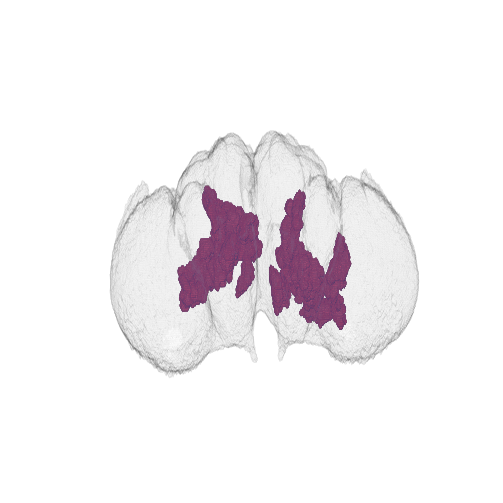

In [138]:
#[40,85] '#F5F5F5'
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
# fig = visualize_mesh_matplotlib(verts_file, faces_file, roi_vertices=verts_r, roi_faces=faces_r, elev=10, azim=-85)
visualize_mesh_matplotlib(verts, faces, roi_vertices=verts_region, roi_faces=faces_region, elev=40, azim=85,ax=ax)
# plt.savefig(os.path.join(save_dir,'AVLP_3D.png'), dpi=300, bbox_inches='tight', transparent=True)

In [139]:
glom_path=os.path.join(later_dir,'lc_glom_masks','glom_mask_4_r_w_LC10.nii.gz')
nifti_img = nib.load(glom_path) 

In [140]:
image_data = nifti_img.get_fdata()
print(f"Image data shape: {image_data.shape}")
print(f"Image data type: {image_data.dtype}")

Image data shape: (1652, 768, 479)
Image data type: float64


In [141]:
glom_csv_path=os.path.join(later_dir,'lc_glom_masks','vpn_types.csv')
glom_list = []
with open(glom_csv_path, 'r', newline='') as file:
    reader = csv.reader(file)
    glom_list=list(reader)
glom_list=np.asarray(glom_list[:-1])

In [142]:
row=np.where(glom_list=='LC4')[0]
alias=glom_list[row]
alias

array([['31', 'LC4']], dtype='<U9')

In [143]:
glom_list[:,0][1:].astype(int)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [144]:
lc_mask=np.where(np.isin(image_data,glom_list[:,0][1:].astype(int)), image_data, np.nan)

In [145]:
print(lc_mask.shape)
print(np.count_nonzero(~np.isnan(lc_mask)))

(1652, 768, 479)
730158


In [146]:
new_resolution=(2,2,2)
use_voxels=False
fixed_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/JRC2018_FEMALE_38um_iso_16bit.nii"
res_JRC2018 = (0.38, 0.38, 0.38)
fixed_jrc = np.asarray(nib.load(fixed_path).get_fdata().squeeze(), dtype='float32')
fixed_jrc = ants.from_numpy(fixed_jrc[:,:,::-1])
fixed_jrc.set_spacing(res_JRC2018)
brain = ants.resample_image(fixed_jrc,new_resolution,use_voxels=use_voxels)
print('Loaded JRC2018')

Loaded JRC2018


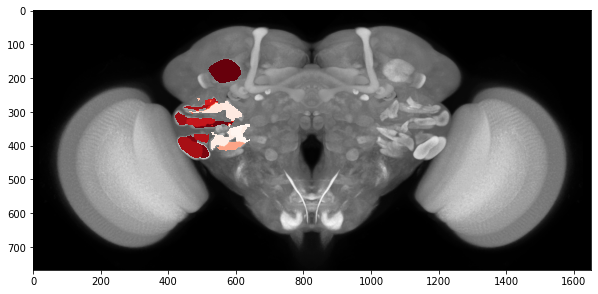

In [147]:
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.max(fixed_jrc.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(lc_mask,axis=-1).T,cmap='Reds_r')

In [148]:
lc_mask = ants.from_numpy(lc_mask[:,:,::-1])
lc_mask.set_spacing(res_JRC2018)
brain_lc = ants.resample_image(lc_mask,new_resolution,use_voxels=use_voxels)
print(f'resampled lc mask to {np.shape(brain_lc)}')

resampled lc mask to (314, 146, 91)


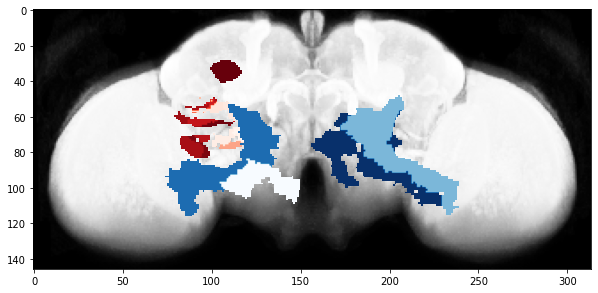

In [149]:
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(brain_lc.numpy(),axis=-1).T,cmap='Reds_r')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='Blues_r')

In [ ]:
downsampled_full_res_superclust['inc'].shape

In [ ]:
behave_dict_total['inc'].shape

In [ ]:
bin_size=5
downsampled_behave_dict={}
for behave in behave_dict_total:
    num_bins=int((behave_dict_total[behave].shape[-1]+1)/bin_size)
    start=0
    downsampled_behave=[]
    for i in range(num_bins):
        end=start+bin_size
        avg_time=np.mean(behave_dict_total[behave][...,start:end],axis=-1)
        downsampled_behave.append(avg_time)
        start=end
    downsampled_behave=np.asarray(downsampled_behave) #.T
#     print(np.shape(downsampled_superclust))
    downsampled_behave_dict[behave]=downsampled_behave

In [ ]:
downsampled_behave_dict[b_1].shape

In [ ]:
full_res_to_use=downsampled_behave_dict
brain_1=full_res_to_use[b_1]
masked_nonan_1=np.where(np.isin(giant_labels_anat,interesting),brain_1, np.nan)
# masked_nonan_1=np.where(np.isin(giant_labels_anat,top_indices[0]),brain_1, np.nan)
masked_nonan_1=np.nan_to_num(masked_nonan_1)
brain_2=full_res_to_use[b_2]
masked_nonan_2=np.where(np.isin(giant_labels_anat,interesting),brain_2, np.nan)
# masked_nonan_2=np.where(np.isin(giant_labels_anat,top_indices[0]),brain_2, np.nan)
masked_nonan_2=np.nan_to_num(masked_nonan_2)
brain_3=full_res_to_use['dec']
masked_nonan_3=np.where(np.isin(giant_labels_anat,interesting),brain_3, np.nan)
masked_nonan_3=np.nan_to_num(masked_nonan_3)

In [ ]:
vmax=0.05
ax_as=1.5
# ax_as='auto'
fig,axs=plt.subplots(1,5,figsize=(25,8),constrained_layout=True)
for i in range(5):
    tp=i
    plot=explode_plot(masked_nonan_1,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(plot[170:,:]) 
    axs[i].axis('off')
    axs[i].set_aspect(ax_as)

plt.show()

In [ ]:
fig,axs=plt.subplots(1,5,figsize=(25,8),constrained_layout=True)
for i in range(5):
    tp=i
    plot=explode_plot(masked_nonan_2,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(plot[170:,:]) 
    axs[i].axis('off')
    axs[i].set_aspect(ax_as)

plt.show()

In [ ]:
fig,axs=plt.subplots(1,5,figsize=(25,8),constrained_layout=True)
for i in range(5):
    tp=i
    plot=explode_plot(masked_nonan_3,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(plot[170:,:]) 
    axs[i].axis('off')
    axs[i].set_aspect(ax_as)

plt.show()

In [ ]:
tp=2
during_1=explode_plot(masked_nonan_1,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
tp=0
before_1=explode_plot(masked_nonan_1,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)

tp=2
during_2=explode_plot(masked_nonan_2,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
tp=0
before_2=explode_plot(masked_nonan_2,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)



In [ ]:
ax_as=1.5
fig,axs=plt.subplots(2,2,figsize=(10,10))
axs[0,0].imshow(before_1[170:,:]) 
axs[0,0].axis('off')
axs[0,0].set_title('before',fontsize=50)
axs[0,0].set_aspect(ax_as)
axs[0,1].imshow(during_1[170:,:]) 
axs[0,1].axis('off')
axs[0,1].set_title('during',fontsize=50)
axs[0,1].set_aspect(ax_as)
axs[1,0].imshow(before_2[170:,:]) 
axs[1,0].axis('off')
axs[1,0].set_aspect(ax_as)
axs[1,1].imshow(during_2[170:,:]) 
axs[1,1].axis('off')
axs[1,1].set_aspect(ax_as)

In [ ]:
tp=2
vmax=0.02
ex_f=explode_plot(downsampled_full_res_superclust['flat'],vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
ex_i=explode_plot(downsampled_full_res_superclust['inc'],vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
ex_d=explode_plot(downsampled_full_res_superclust['dec'],vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)


In [ ]:
ax_as=1.5
fig,axs=plt.subplots(1,3,figsize=(50,50))
axs[0].imshow(ex_i[170:,:]) #this was made with cmap=hot
axs[0].axis('off')
axs[0].set_title('inc',fontsize=50)
axs[0].set_aspect(ax_as)
axs[1].imshow(ex_d[170:,:]) #this was made with cmap=hot
axs[1].axis('off')
axs[1].set_title('dec',fontsize=50)
axs[1].set_aspect(ax_as)
axs[2].imshow(ex_f[170:,:]) #this was made with cmap=hot
axs[2].axis('off')
axs[2].set_title('flat',fontsize=50)
axs[2].set_aspect(ax_as)

In [ ]:
def herarchy_clust(superclust,t):
    cmat=np.corrcoef(superclust)
    shape=np.shape(cmat)
    clust_labels=np.arange(0,shape[0])
    dist_matrix = 1 - cmat
    linkage= sch.linkage(pdist(cmat),method='complete',metric='euclidean',optimal_ordering=True)
    t=t
    clusters = sch.fcluster(linkage, t=t, criterion='distance')
    print(np.unique(clusters))
    n_clusters=len(np.unique(clusters))
    
    to_sort=superclust 
    clustered={}
    clus_num=list(np.unique(clusters))
    for val in clus_num:
        clustered[val]={}
        for i in range(to_sort.shape[0]):
            cluster_val=clusters[i]
            if cluster_val==val:
                clustered[val][i]=to_sort[i,:]
    temp_clustered_final={}
    cluster_dict=clustered
    for cluster in clustered:
        cluster=cluster-1
        temp_clustered_final[cluster]={}
        sort_idx=np.argsort(np.mean(list(cluster_dict[cluster+1].values()), axis=1))
        names=list(cluster_dict[cluster+1].keys())
        for idx in sort_idx:
            key=names[idx]
            temp_clustered_final[cluster][key]=cluster_dict[cluster+1][key]
    area_size=[]
    for clust in temp_clustered_final:
        area_size.append(len(temp_clustered_final[clust].keys()))
    order=np.argsort(area_size)
    h_clustered={}
    for val in order:
        c=temp_clustered_final[val]
        for name in c:
            h_clustered[name]=c[name]
    return linkage, clusters, clustered, cmat, clust_labels, h_clustered

In [ ]:
def plot_h_clustering(links,clusts,clustered,cmat,labels,h_clustered, color_map):
    cmat=cmat
    linkage=links
    clusters=clusts
    def get_color(k):
        if k < len(cmat):
            return color_map[(clusters[k] - 1) % len(color_map)]
        else:
            # For merges, get the color of the smaller cluster being merged
            left = int(linkage[k - len(cmat), 0])
            right = int(linkage[k - len(cmat), 1])
            return get_color(left)  # You could also choose right, or blend the colors

    def link_color_func(k):
        if k < len(cmat):
            return get_color(k)
        else:
            # Check if the merge is above the threshold
            merge_height = linkage[k - len(cmat), 2]
            if merge_height > t:
                return 'black'
            else:
                return get_color(k)

    fig,axs = plt.subplots(figsize=(3, 10))

    sch.dendrogram(linkage, p=len(cmat), truncate_mode='lastp', ax=axs,
                   color_threshold=t, orientation='left',labels=flat_labels,link_color_func=link_color_func)
    # sch.dendrogram(linkage, labels=list(avg_behave.keys()))
    # plt.title('Hierarchical Clustering Based on Correlation')
    axs.set_xticks([])
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    axs.spines['bottom'].set_visible(False)
    axs.spines['left'].set_visible(False)
    
    cmat_h=h_clustered
    cmat_ht=np.corrcoef(list(cmat_h.values()))
    fig,axs = plt.subplots(figsize=(10,10))
    sns.heatmap(cmat_ht, cmap='YlGnBu', cbar=True, ax=axs, square=True, 
                cbar_kws={"shrink": 0.8},yticklabels=np.asarray(list(cmat_h.keys())),
               xticklabels=np.asarray(list(cmat_h.keys())))
    
    to_plot=h_clustered
    clustered=clustered
    vmax=0.03
    vmin=-0.03
    fig,axs=plt.subplots(figsize=(10,15))
    sns.heatmap(list(to_plot.values()),yticklabels=[], cmap='PRGn_r', 
                cbar=False, ax=axs, center=0,
               vmax=vmax,vmin=vmin)
    total=0
    axs.axhline(y=0.5, color=color_map[0], lw=3)
    for cluss in clustered:
        clus_size=np.shape(list(clustered[cluss].keys()))[0]
        total+=clus_size
        if total<500:
            axs.axhline(y=(total), color=color_map[cluss], lw=3)

In [ ]:
shape=superclust_dict['flat'].shape


In [296]:
t=8
flat_links,flat_clusts, flat_clusted, flat_cmat, flat_labels, flat_h_clustered=herarchy_clust(superclust_dict['flat'],t=t)
inc_links,inc_clusts, inc_clusted, inc_cmat, inc_labels, inc_h_clustered=herarchy_clust(superclust_dict['inc'],t=t)
dec_links,dec_clusts, dec_clusted, dec_cmat, dec_labels, dec_h_clustered=herarchy_clust(superclust_dict['flat'],t=t)

[1 2 3 4 5]
[1 2 3 4]
[1 2 3 4 5]


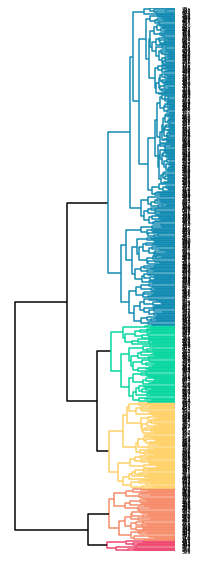

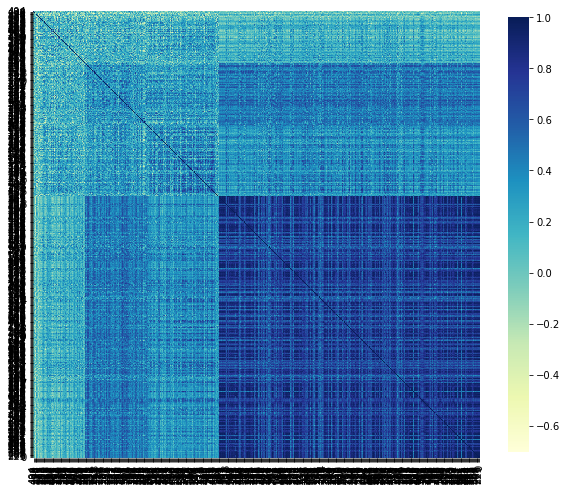

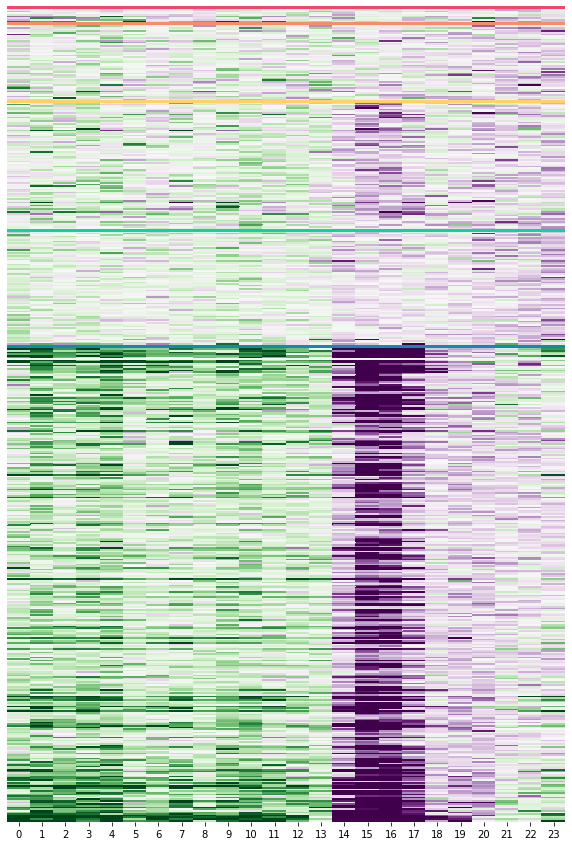

In [297]:
plot_h_clustering(flat_links,flat_clusts, flat_clusted, flat_cmat, flat_labels, flat_h_clustered, color_map=rainbow_color)

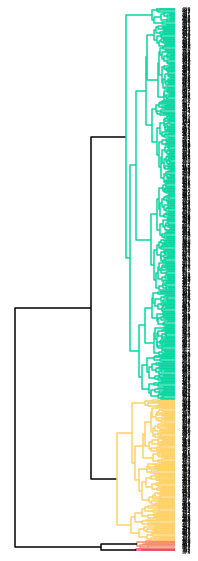

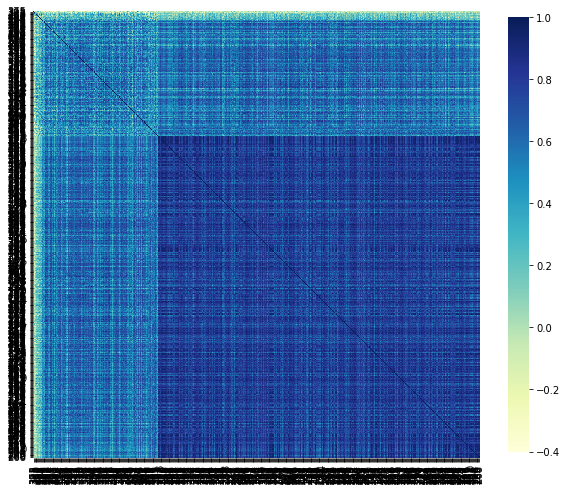

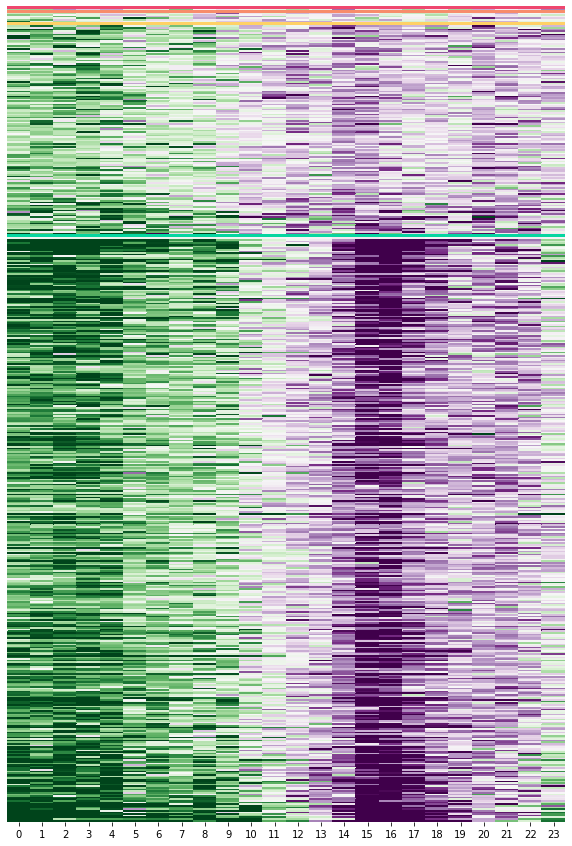

In [298]:
plot_h_clustering(inc_links,inc_clusts, inc_clusted, inc_cmat, inc_labels, inc_h_clustered, color_map=rainbow_color)

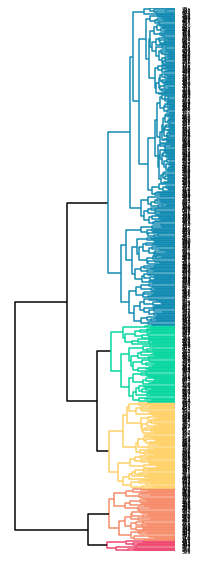

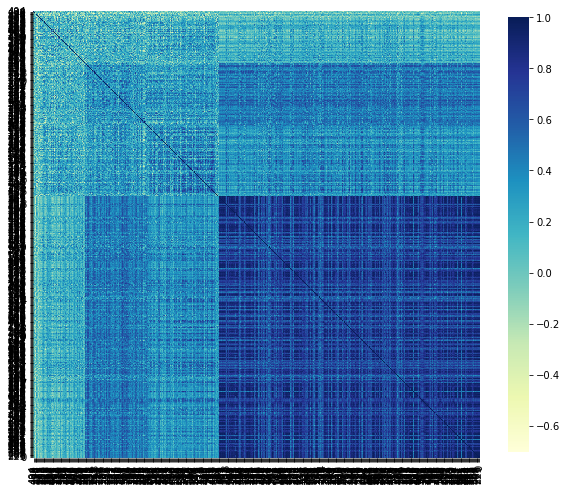

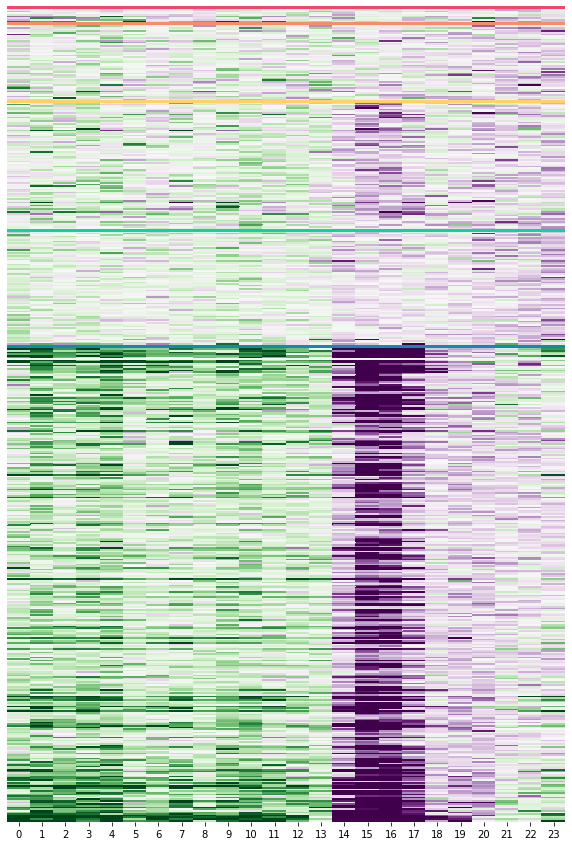

In [299]:
plot_h_clustering(dec_links,dec_clusts, dec_clusted, dec_cmat, dec_labels, dec_h_clustered, color_map=rainbow_color)

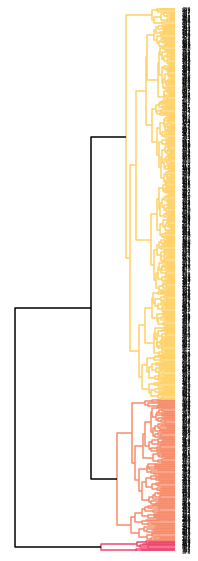

In [284]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0', '#118AB2', '#6A4C93', '#6d0d25'])
cmat=inc_cmat
linkage=inc_links
clusters=inc_clusts
def get_color(k):
    if k < len(cmat):
        return rainbow_color[(clusters[k] - 1) % len(rainbow_color)]
    else:
        # For merges, get the color of the smaller cluster being merged
        left = int(linkage[k - len(cmat), 0])
        right = int(linkage[k - len(cmat), 1])
        return get_color(left)  # You could also choose right, or blend the colors

def link_color_func(k):
    if k < len(cmat):
        return get_color(k)
    else:
        # Check if the merge is above the threshold
        merge_height = linkage[k - len(cmat), 2]
        if merge_height > t:
            return 'black'
        else:
            return get_color(k)

fig,axs = plt.subplots(figsize=(3, 10))

sch.dendrogram(linkage, p=len(cmat), truncate_mode='lastp', ax=axs,
               color_threshold=t, orientation='left',labels=flat_labels,link_color_func=link_color_func)
# sch.dendrogram(linkage, labels=list(avg_behave.keys()))
# plt.title('Hierarchical Clustering Based on Correlation')
axs.set_xticks([])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.spines['bottom'].set_visible(False)
axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'superclust_h_dendrogram.png'), dpi=300, bbox_inches='tight')   
# plt.savefig(os.path.join(save_dir,'superclust_h_dendrogram.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
plt.show()

<AxesSubplot:>

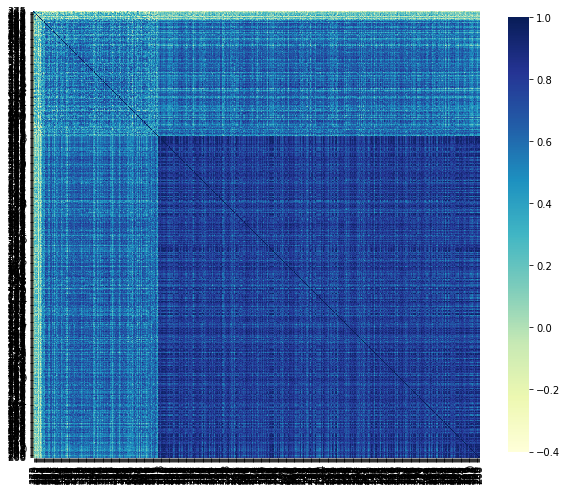

In [285]:
cmat_h=inc_h_clustered
cmat_ht=np.corrcoef(list(cmat_h.values()))
fig,axs = plt.subplots(figsize=(10,10))
sns.heatmap(cmat_ht, cmap='YlGnBu', cbar=True, ax=axs, square=True, 
            cbar_kws={"shrink": 0.8},yticklabels=np.asarray(list(cmat_h.keys())),
           xticklabels=np.asarray(list(cmat_h.keys())))

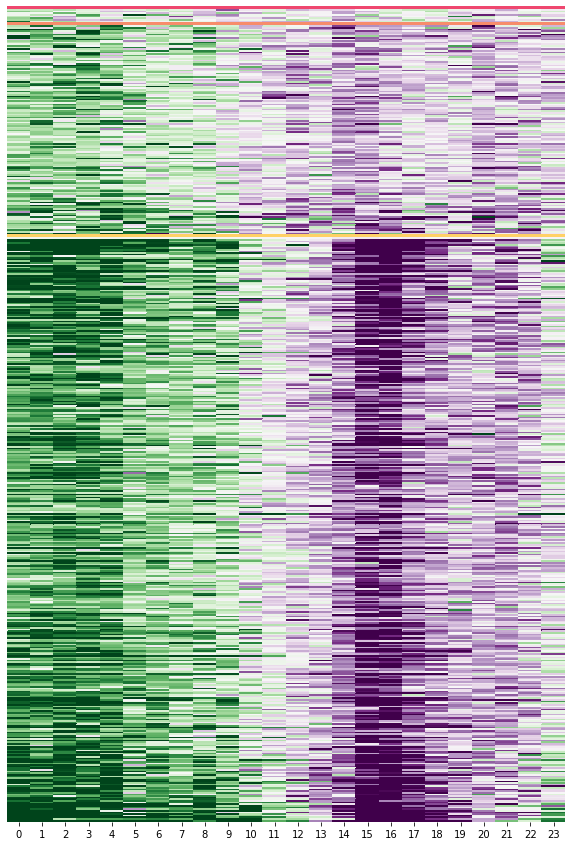

In [286]:
to_plot=inc_h_clustered
clustered=inc_clusted
vmax=0.03
vmin=-0.03
fig,axs=plt.subplots(figsize=(10,15))
#yticklabels=np.asarray(list(h_clustered.keys())),
sns.heatmap(list(to_plot.values()),yticklabels=[], cmap='PRGn_r', 
            cbar=False, ax=axs, center=0,
           vmax=vmax,vmin=vmin)
# axs.imshow(to_plot.values(),norm=colors.DivergingNorm(0), vmin=vmin, cmap='PRGn_r')
# axs.set_aspect(ax_ap)
# axs.label_outer()
# axs.axvline(x=5, ymin=0, ymax=1, ls='--', color='k', lw=2)
# axs.axvline(x=15, ymin=0, ymax=1, ls='--', color='k', lw=2)
total=0
axs.axhline(y=0.5, color=rainbow_color[0], lw=3)
for cluss in clustered:
    clus_size=np.shape(list(clustered[cluss].keys()))[0]
    total+=clus_size
    if total<500:
        axs.axhline(y=(total), color=rainbow_color[cluss], lw=3)